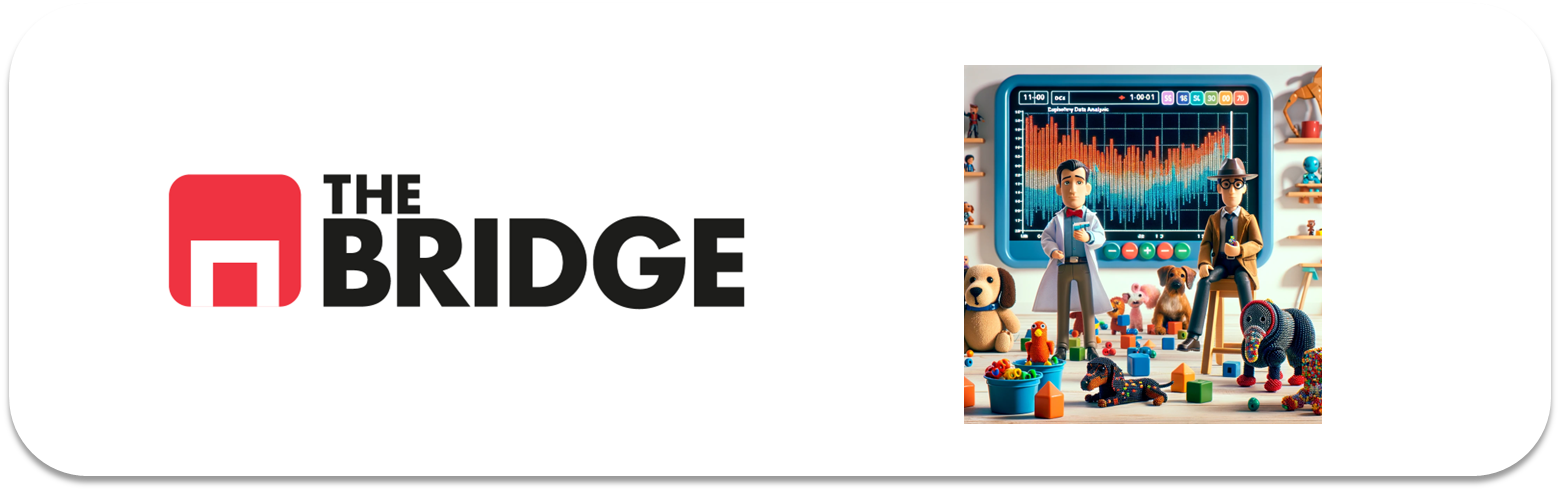

## PRACTICA OBLIGATORIA: ANÁLISIS MULTIVARIANTE

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [2]:
import pandas as pd
import seaborn as sns

from bootcampviztools import plot_categorical_relationship_fin, pinta_distribucion_categoricas, plot_grouped_histograms,\
    plot_grouped_boxplots, plot_combined_graphs, plot_categorical_numerical_relationship, bubble_plot,\
        grafico_dispersion_con_correlacion
from scipy.stats import chi2_contingency, mannwhitneyu


## #1 TITANIC

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [3]:
df_titanic = pd.read_csv("../data/titanic.csv")

### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [4]:
df_titanic.drop(columns=["deck","survived","pclass","embarked"], inplace= True)

### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [5]:
df_titanic["family_members"] = df_titanic.parch + df_titanic.sibsp

In [6]:
df_titanic = df_titanic.drop(["parch","sibsp"], axis = 1)

### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [7]:
df_titanic.loc[df_titanic.embark_town.isna(), "embark_town"] = df_titanic.embark_town.mode()[0]

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [8]:
es_woman = df_titanic.who == "woman"
es_child = df_titanic.who == "child"
es_man = df_titanic.who == "man"

media_woman = df_titanic.loc[es_woman,"age"].mean()
media_child = df_titanic.loc[es_child,"age"].mean()
media_man = df_titanic.loc[es_man,"age"].mean()

es_age_nulo = df_titanic.age.isna()

df_titanic.loc[es_woman & es_age_nulo, "age"] = media_woman
df_titanic.loc[es_child & es_age_nulo, "age"] = media_child
df_titanic.loc[es_man & es_age_nulo, "age"] = media_man

### 1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. *En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?*

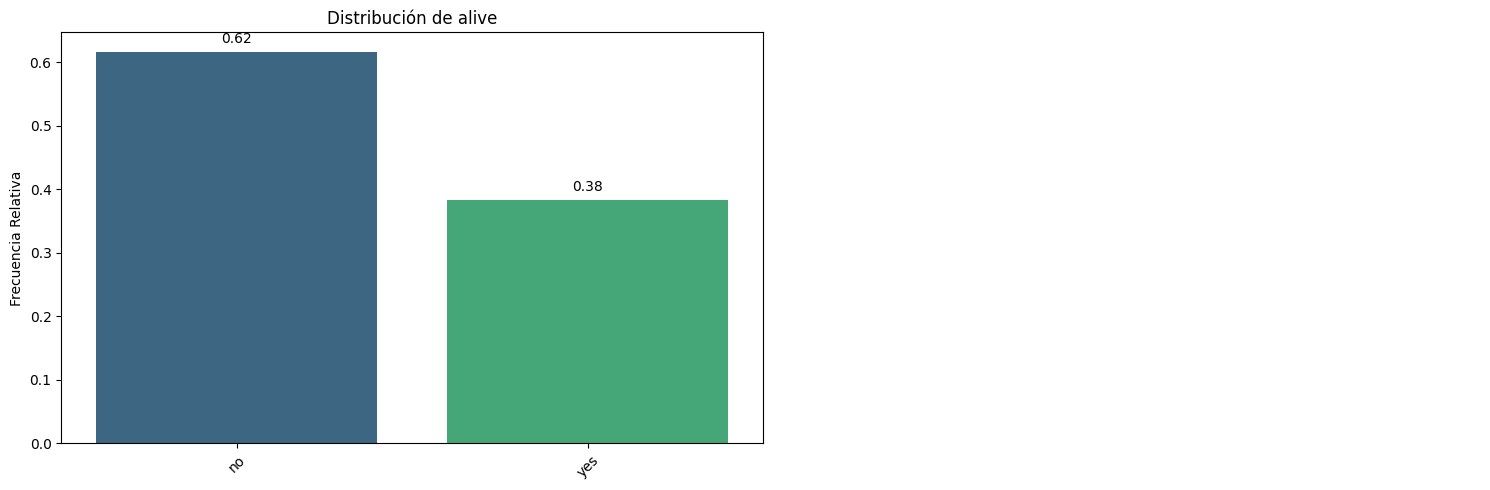

In [9]:
pinta_distribucion_categoricas(df_titanic,["alive"], relativa= True, mostrar_valores= True)

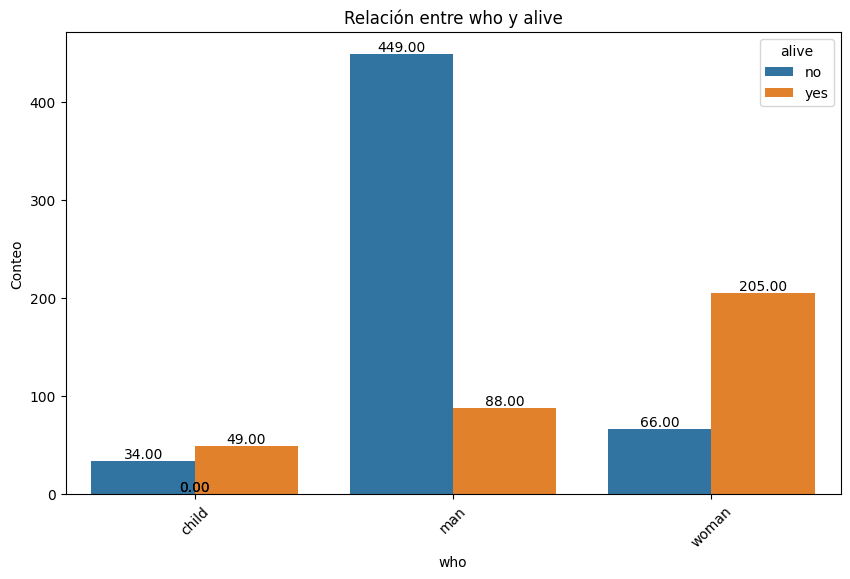

In [10]:
plot_categorical_relationship_fin(df_titanic, "who","alive", show_values= True)

In [11]:
df_titanic.loc[df_titanic.who == "woman"].age.min()

np.float64(16.0)

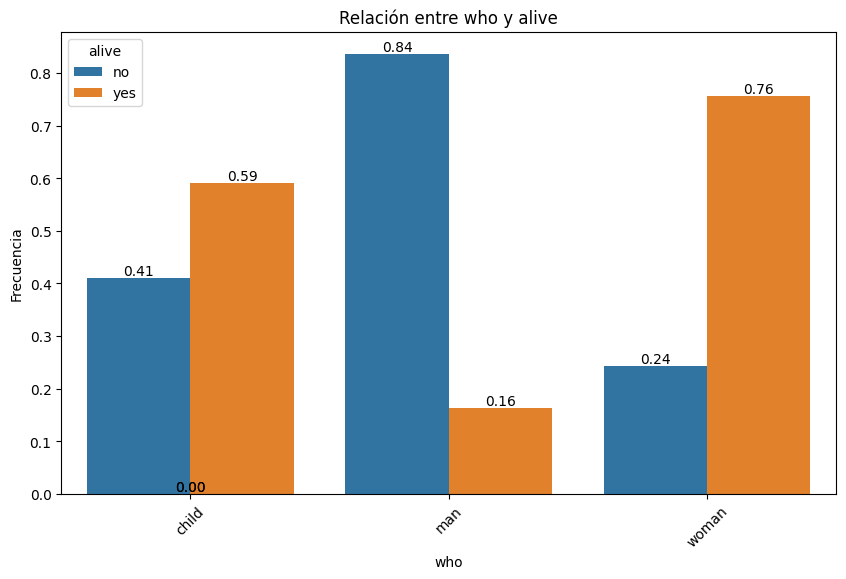

In [12]:
plot_categorical_relationship_fin(df_titanic, "who","alive", relative_freq= True, show_values= True)

#### Análisis mortandad por género.

En términos absolutos murieron más hombres que niños (449 vs 34) y que mujeres (449 vs 66).  
En términos relativos también. Hombres murieron mucho más, visual y porcentualmente (84% vs 41% & 24%)


In [13]:
tabla_contingencia = pd.crosstab(df_titanic["alive"],df_titanic["who"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

print(tabla_contingencia)
print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

who    child  man  woman
alive                   
no        34  449     66
yes       49   88    205
Valor Chi-Cuadrado: 283.923050324233
P-Value: 2.2227620817798914e-62
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[ 51.14141414 330.87878788 166.97979798]
 [ 31.85858586 206.12121212 104.02020202]]


#### Correlación estadística

El p-valor es muy inferior a 0.05, lo que nos indica que podemos descartar la hipótesis nula de no correlación. Hay una clara relación entre género y mortandad. 

In [14]:
def tricategorical_analysis(df, directora, otras, relativa = False, muestra_valores = False):
    col_directora = directora
    col_1 = otras[0]
    col_2 = otras[1]
    diccionario_multivariante = {}
    for valor in df[col_directora].unique():
        diccionario_multivariante[valor] = df.loc[df[col_directora] == valor,[col_2,col_1]] 

    for valor,df_datos in diccionario_multivariante.items():
        print(f"Respuesta {valor}:")
        plot_categorical_relationship_fin(df_datos,col_2,col_1, relative_freq= relativa, show_values= muestra_valores)

Respuesta Third:


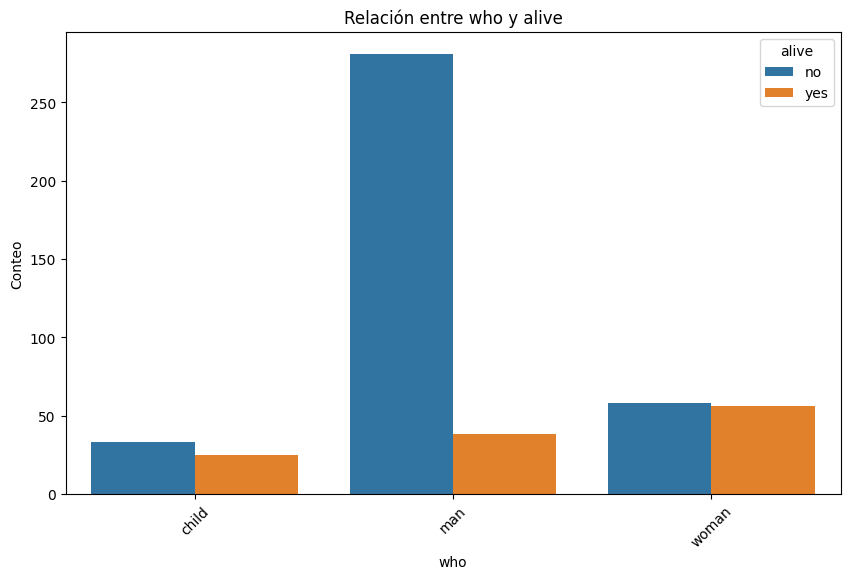

Respuesta First:


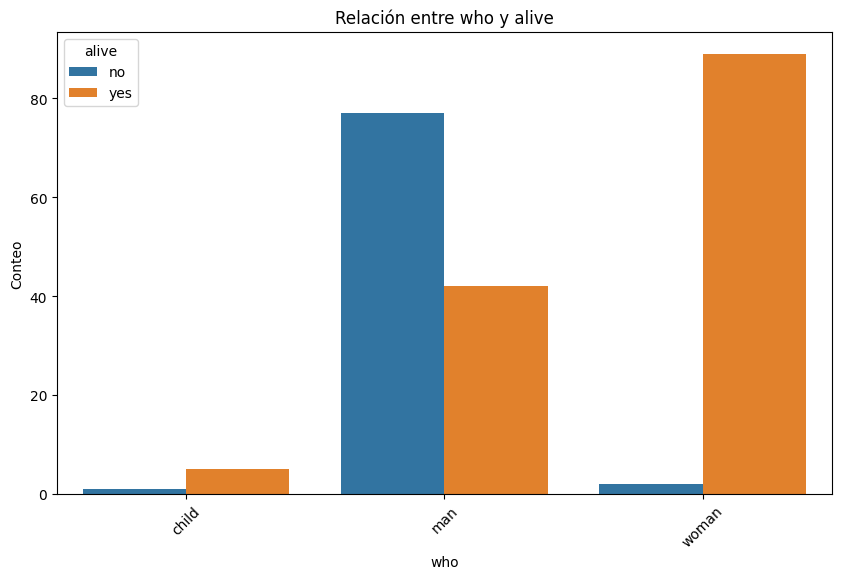

Respuesta Second:


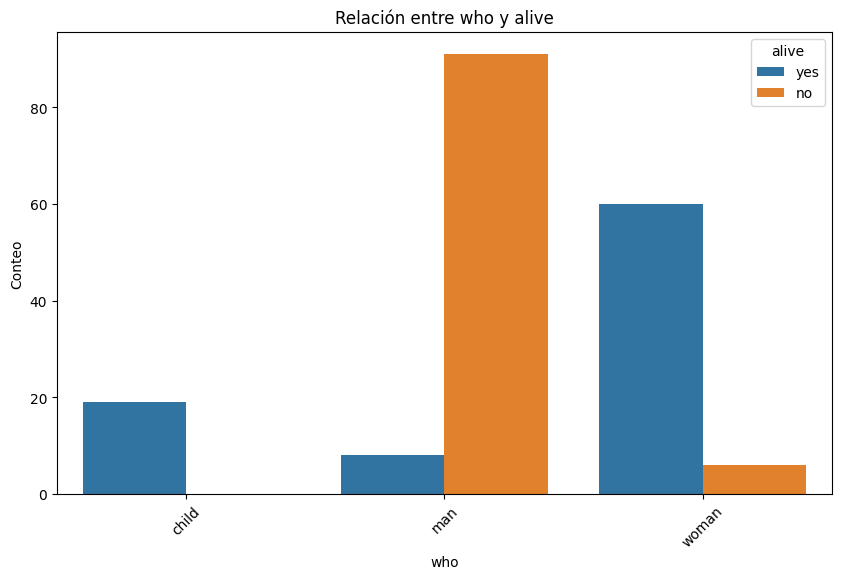

In [15]:
tricategorical_analysis(df_titanic, "class", ["alive","who"])

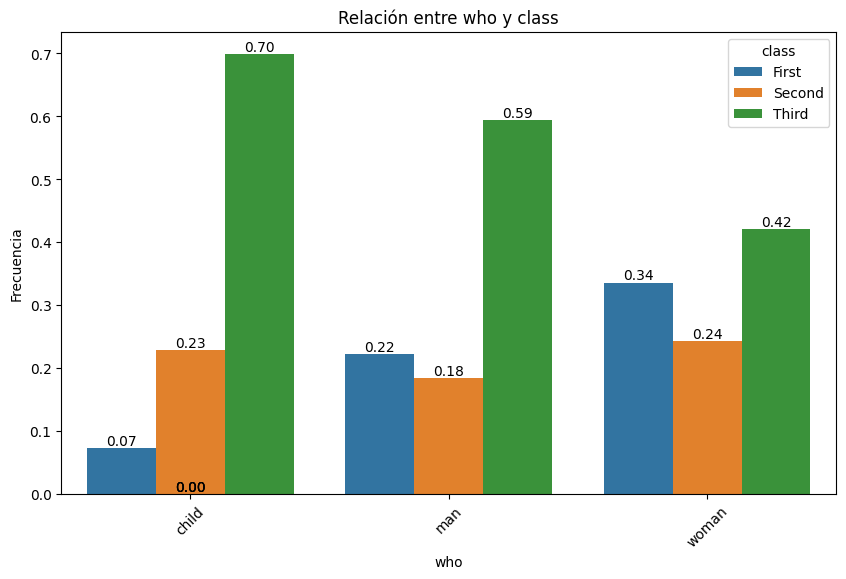

In [16]:
plot_categorical_relationship_fin(df_titanic,"who","class", relative_freq= True, show_values= True)

Había muchos más niños y adultos hombres en tercera que mujeres en proporción a otras clases. 

El sexo influyó, pero también influyó la clase. Si estaban en primera, sobrevivir era mucho más probable, independientemente de tu género. A medida que bajamos de clase es menos probable sobrevivir, e influye mucho más tu demografía.

2. *En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?*

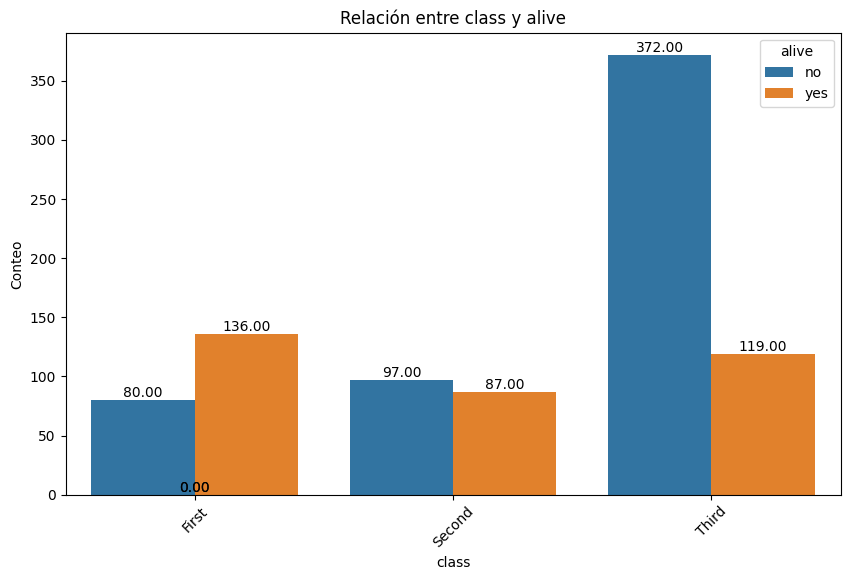

In [17]:
plot_categorical_relationship_fin(df_titanic, "class","alive", show_values = True)

Claramente, se puede apreciar que la clase influyó mucho en la tasa de supervivencia. La tasa de supervivencia sólo fue positiva en primera, y muy negativa en tercera. 

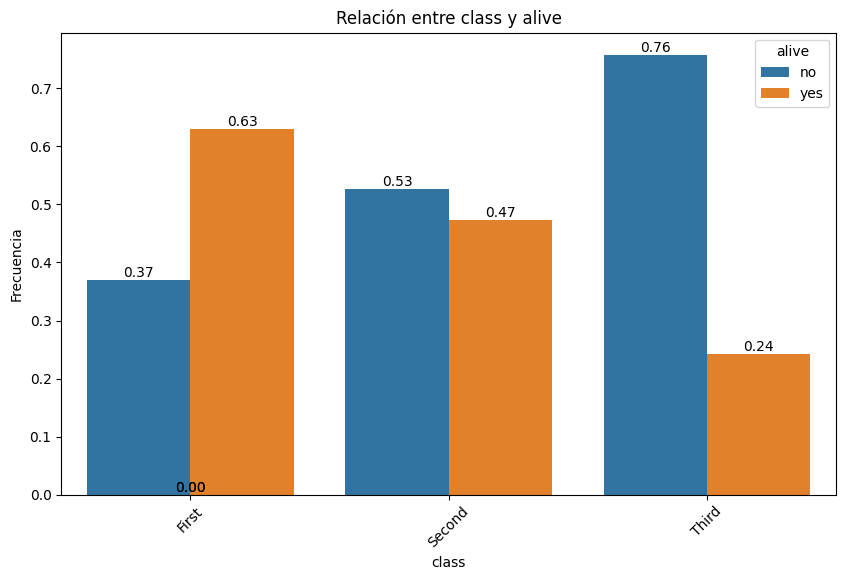

In [18]:
plot_categorical_relationship_fin(df_titanic, "class","alive", relative_freq= True, show_values= True)

In [19]:

tabla_contingencia = pd.crosstab(df_titanic["alive"],df_titanic["class"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 102.88898875696056
P-Value: 4.549251711298793e-23
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[133.09090909 113.37373737 302.53535354]
 [ 82.90909091  70.62626263 188.46464646]]


El p-valor nos indica que la correlación entre clase y tasa de supervivencia es muy alta. 

3. *¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?*

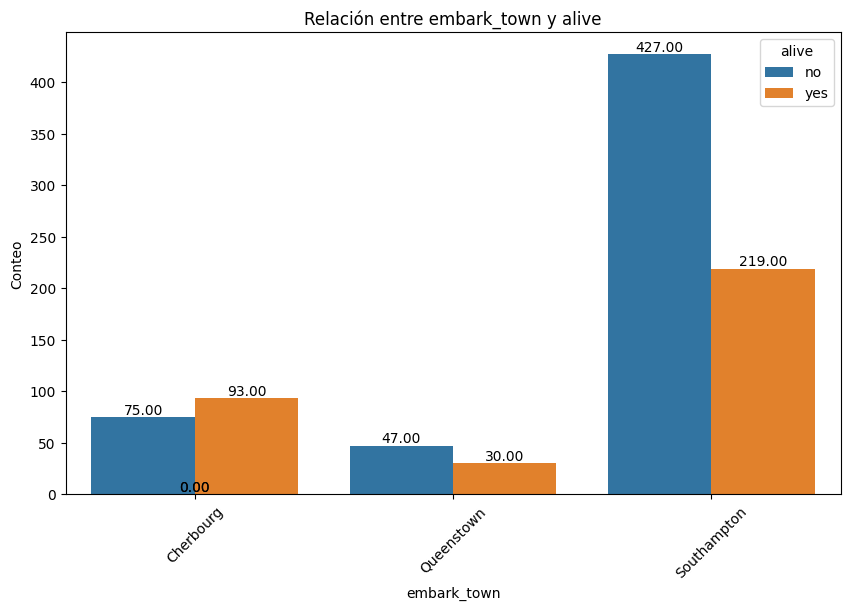

In [20]:
plot_categorical_relationship_fin(df_titanic, "embark_town","alive", show_values= True)

In [21]:
df_titanic.groupby("embark_town", as_index = False)["alive"].value_counts(normalize = False)

,embark_town,alive,count
0,Cherbourg,yes,93
1,Cherbourg,no,75
2,Queenstown,no,47
3,Queenstown,yes,30
4,Southampton,no,427
5,Southampton,yes,219


In [22]:
df_titanic.groupby("embark_town", as_index = False)["alive"].value_counts(normalize = True)

,embark_town,alive,proportion
0,Cherbourg,yes,0.553571
1,Cherbourg,no,0.446429
2,Queenstown,no,0.610390
3,Queenstown,yes,0.389610
4,Southampton,no,0.660991
5,Southampton,yes,0.339009


Se observa una mayor supervivencia del puerto de Cherbourg. Quizás porque la clase era diferente

In [23]:
df_titanic.groupby("embark_town", as_index = False)["class"].value_counts(normalize = True)

,embark_town,class,proportion
0,Cherbourg,First,0.505952
1,Cherbourg,Third,0.392857
2,Cherbourg,Second,0.101190
3,Queenstown,Third,0.935065
4,Queenstown,Second,0.038961
5,Queenstown,First,0.025974
6,Southampton,Third,0.546440
7,Southampton,Second,0.253870
8,Southampton,First,0.199690


Se observa que Cherbourg tiene la mayor proporción de tripulantes de primera clase

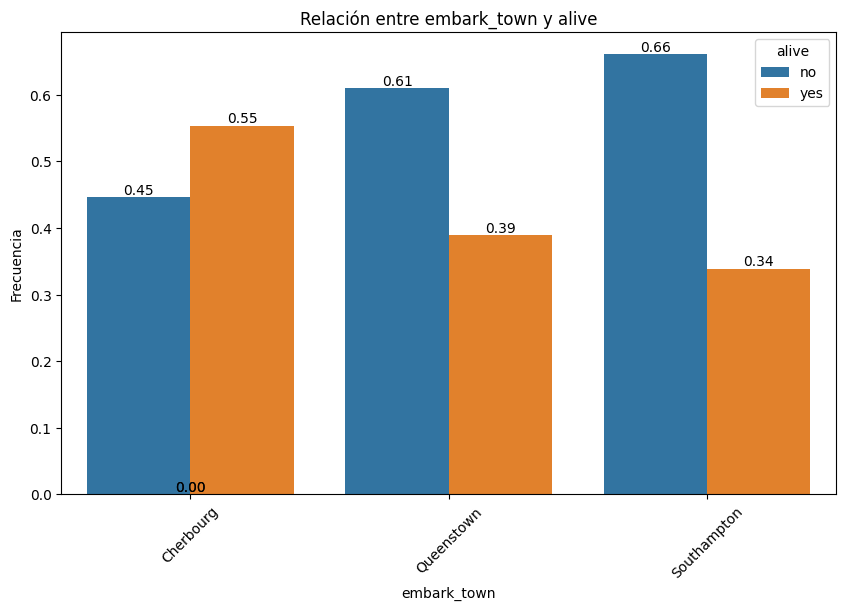

In [24]:
plot_categorical_relationship_fin(df_titanic, "embark_town","alive", show_values= True, relative_freq= True)

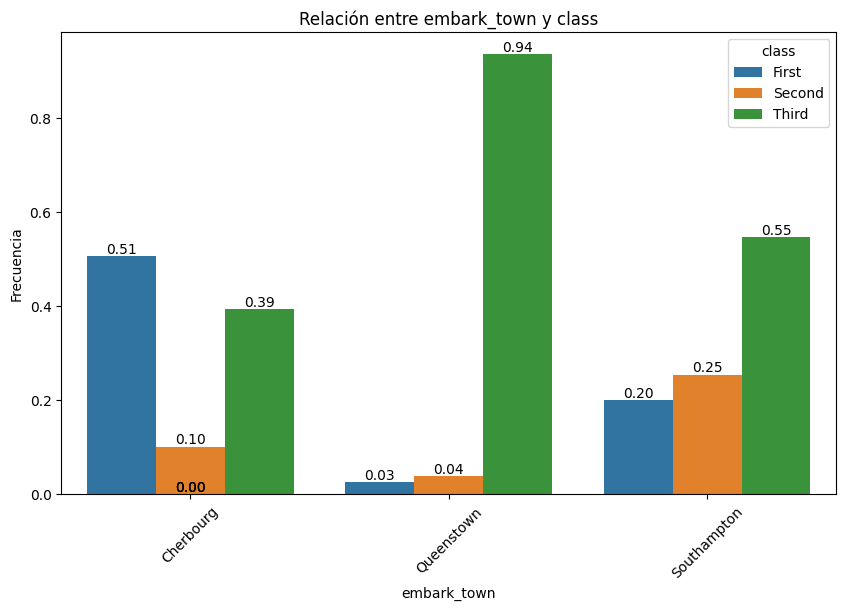

In [25]:
plot_categorical_relationship_fin(df_titanic, "embark_town","class", show_values= True, relative_freq= True)

Se observa una clara diferencia en tasa de supervivencia entre Cherbourg y el resto de puertos. Interesante también que a pesar de ser Queenstown casi completamente de tercera clase tiene más tasa de supervivencia que Southhampton. ¿Quizás haya más familias (más mujeres y más niños con más tasa de supervivencia) en Queenstown, y la tercera clase de Southampton son más hombres?

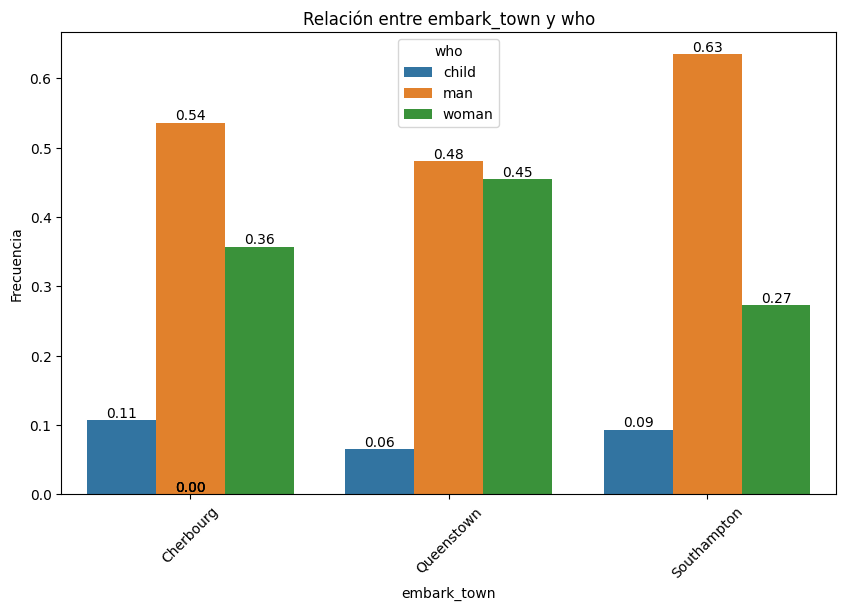

In [26]:
plot_categorical_relationship_fin(df_titanic, "embark_town","who", show_values= True, relative_freq= True)

Efectivamente, en Queenstown hay una cantidad muy parecida de hombres y mujeres, lo cual nos puede indicar familias, mientras que en Southampton hay una mayor cantidad de hombres, quizás trabajadores.

Vamos a hacer el chi valor para comprobar la probabilidad de nuestra hipótesis

In [27]:
tabla_contingencia = pd.crosstab(df_titanic["alive"],df_titanic["embark_town"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 25.964452881874784
P-Value: 2.3008626481449577e-06
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[103.51515152  47.44444444 398.04040404]
 [ 64.48484848  29.55555556 247.95959596]]


El p-valor tan bajo nos indica que claramente hay una relación

Vemos de forma absoluta que el género y la clase influyen mucho en la tasa de supervivencia. Vamos a comprobar la dependencia de clase y género con el puerto de embarque y la tasa de supervivencia con los hombres de tercera clase de todos los puertos para saber si realmente el puerto de embarque tiene una influencia real.

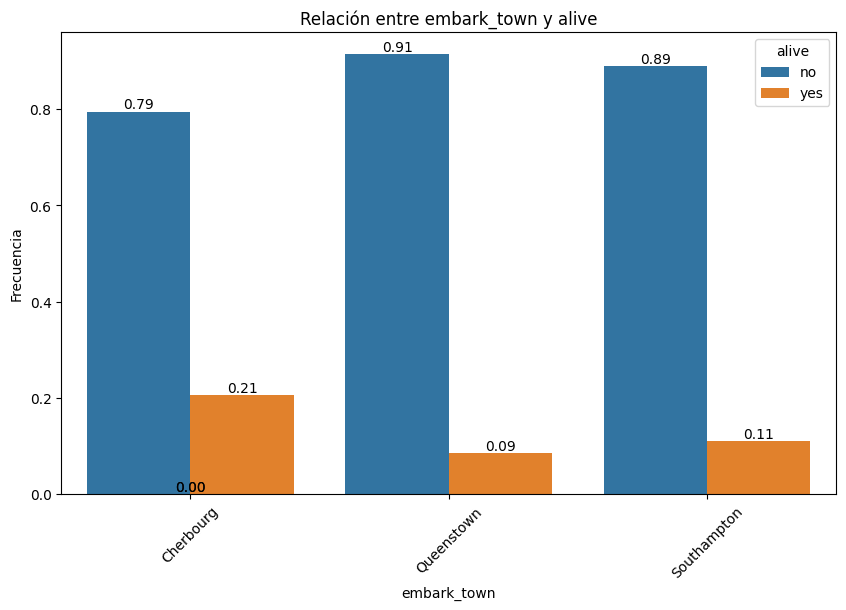

Valor Chi-Cuadrado: 3.3072128132305267
P-Value: 0.1913585459765817
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[ 34.35423197  30.830721   215.81504702]
 [  4.64576803   4.169279    29.18495298]]


In [28]:
df_test = df_titanic.loc[(df_titanic.who == "man") & (df_titanic["class"] == "Third")].copy()

plot_categorical_relationship_fin(df_test,"embark_town","alive", relative_freq= True, show_values= True)

tabla_contingencia = pd.crosstab(df_test["alive"],df_test["embark_town"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Un p-valor de 0.2, o un 20% nos indica que efectivamente el puerto no influye, y la tasa de supervivencia de los hombres de tercera clase de todos los puertos es similar.

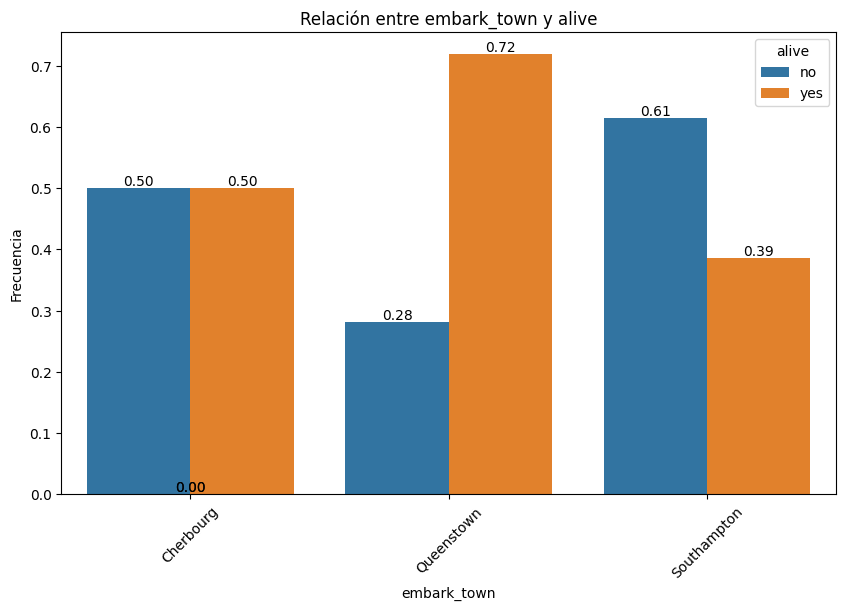

Valor Chi-Cuadrado: 9.750056078465867
P-Value: 0.007634880139676012
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[ 6.10526316 16.28070175 35.61403509]
 [ 5.89473684 15.71929825 34.38596491]]


In [29]:
df_test = df_titanic.loc[(df_titanic.who == "woman") & (df_titanic["class"] == "Third")].copy() # Fijo clase y who, si realmente hay dependencia por otros factores entre ciudad y sobrevivir, debería salir en los test y en las gráficas

plot_categorical_relationship_fin(df_test,"embark_town","alive", relative_freq= True, show_values= True)

tabla_contingencia = pd.crosstab(df_test["alive"],df_test["embark_town"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

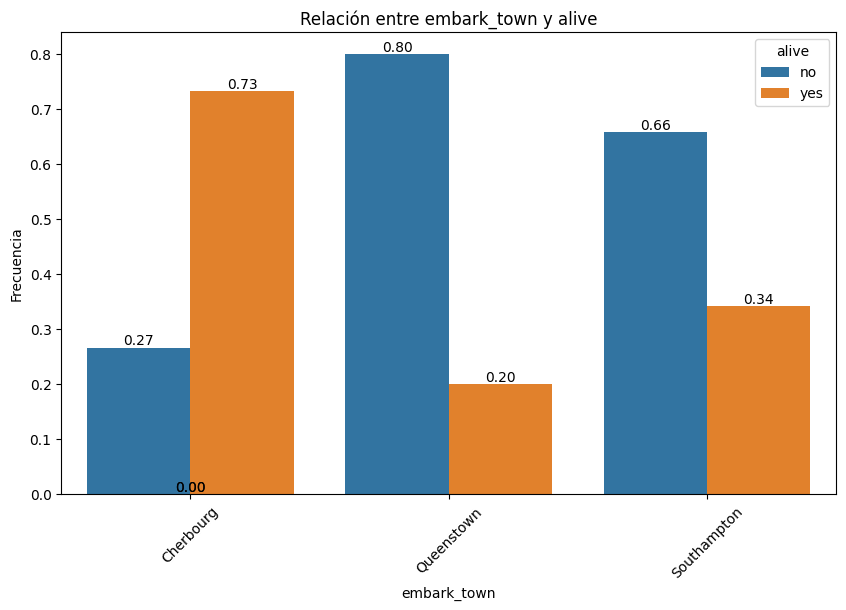

Valor Chi-Cuadrado: 7.903047315257843
P-Value: 0.019225386540995867
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[ 8.53448276  2.84482759 21.62068966]
 [ 6.46551724  2.15517241 16.37931034]]


In [30]:
df_test = df_titanic.loc[(df_titanic.who == "child") & (df_titanic["class"] == "Third")].copy() # Fijo clase y who, si realmente hay dependencia por otros factores entre ciudad y sobrevivir, debería salir en los test y en las gráficas

plot_categorical_relationship_fin(df_test,"embark_town","alive", relative_freq= True, show_values= True)

tabla_contingencia = pd.crosstab(df_test["alive"],df_test["embark_town"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Con un p valor para la relacion entre mujeres de tercera clase de menos de 0.01 y un p valor de menos de 0.02 para los niños de tercera clase, podemos observar que sí hay una correlación entre tasa de supervivencia y puerto de embarque. Quizás por la localización de sus camarotes o las actividades de ese momento.


4. *¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?*

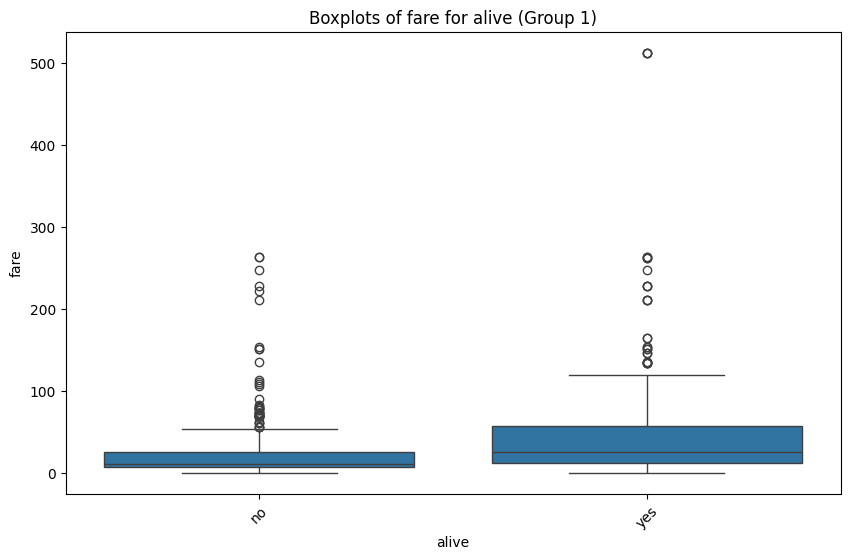

In [31]:
plot_grouped_boxplots(df_titanic,"alive","fare")

Queremos comparar rangos de precio con tasa de supervivencia. Hacemos Mann Whitney.

In [32]:
grupo_a = df_titanic.loc[df_titanic.alive == "yes"]["fare"]
grupo_b = df_titanic.loc[df_titanic.alive == "no"]["fare"]


u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", u_stat)
print("Valor p:", p_valor)

Estadístico U: 129951.5
Valor p: 4.553477179250237e-22


Hay relación entre precio y tasa de supervivencia muy destacado, p valor muy muy bajo.

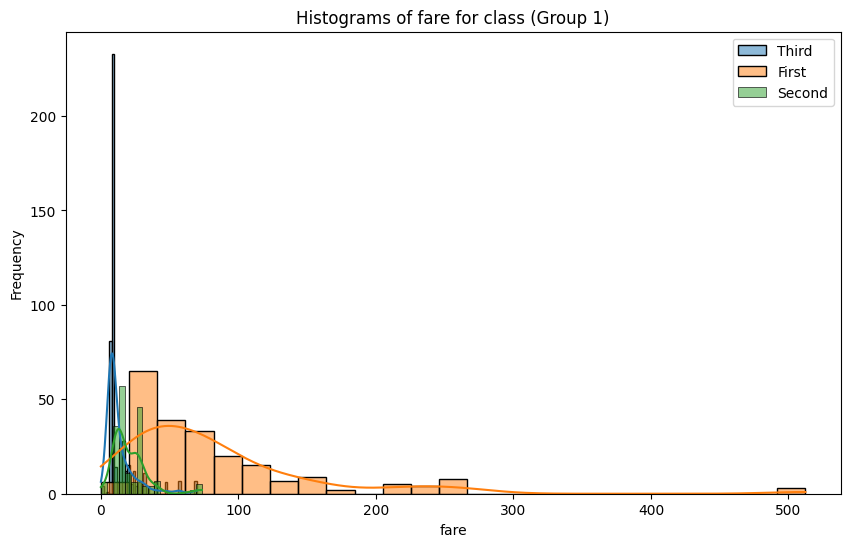

In [33]:
plot_grouped_histograms(df_titanic,"class","fare", group_size = 3)

In [34]:
df_alive = df_titanic.loc[df_titanic.alive == "yes"].copy()
df_dead = df_titanic.loc[df_titanic.alive == "no"].copy()

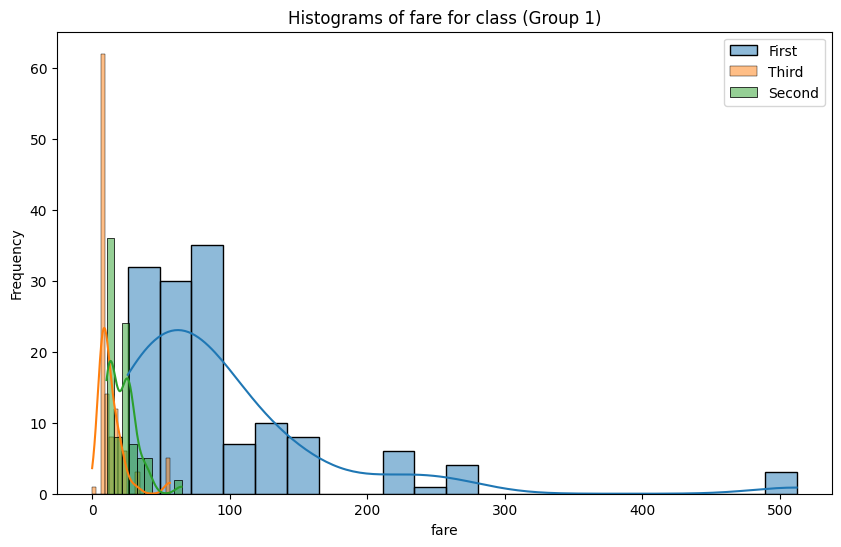

In [35]:
plot_grouped_histograms(df_alive,"class","fare", group_size = 3)

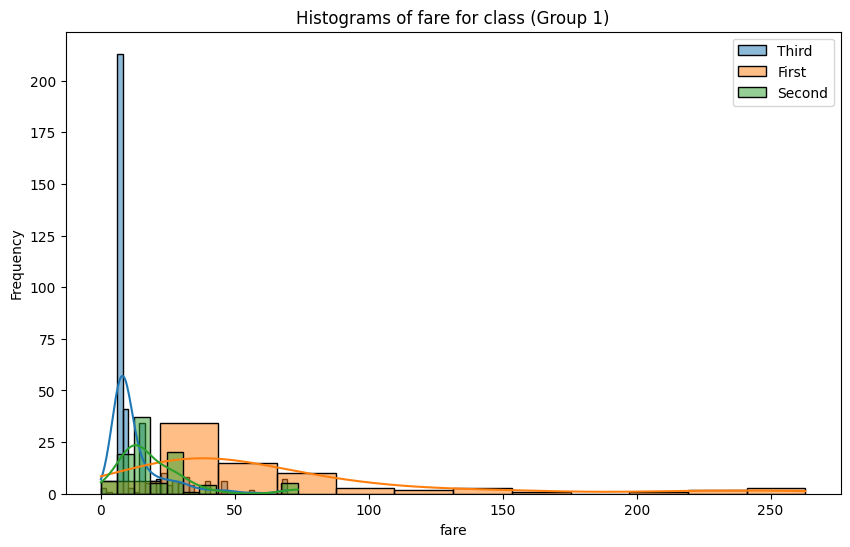

In [36]:
plot_grouped_histograms(df_dead,"class","fare", group_size = 3)

5. *Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?*

In [37]:
df_titanic.loc[df_titanic.fare == 0]

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
179,male,36.000000,0.0,Third,man,True,Southampton,no,True,0
263,male,40.000000,0.0,First,man,True,Southampton,no,True,0
271,male,25.000000,0.0,Third,man,True,Southampton,yes,True,0
277,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
302,male,19.000000,0.0,Third,man,True,Southampton,no,True,0
413,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
466,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
481,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
597,male,49.000000,0.0,Third,man,True,Southampton,no,True,0
633,male,33.173123,0.0,First,man,True,Southampton,no,True,0


All male, all from Southampton, all alone. Probably crew.

In [38]:
df_crew = df_titanic.loc[df_titanic.fare == 0].copy()

In [39]:
df_titanic.loc[df_titanic.fare == df_titanic.fare.max()]

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
258,female,35.0,512.3292,First,woman,False,Cherbourg,yes,True,0
679,male,36.0,512.3292,First,man,True,Cherbourg,yes,False,1
737,male,35.0,512.3292,First,man,True,Cherbourg,yes,True,0



6. *Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.*

In [40]:
def trivariant_analysis(df, directora, cat2, num1, group_size = 3, bins = "auto"):
    col_directora = directora
    col_1 = cat2
    col_2 = num1
    diccionario_multivariante = {}
    for valor in df[col_directora].unique():
        diccionario_multivariante[valor] = df.loc[df[col_directora] == valor,[col_2,col_1]] 

    for valor,df_datos in diccionario_multivariante.items():
        print(f"Respuesta {valor}:")
        plot_grouped_histograms(df_datos,col_1,col_2, group_size= group_size)

Respuesta Southampton:


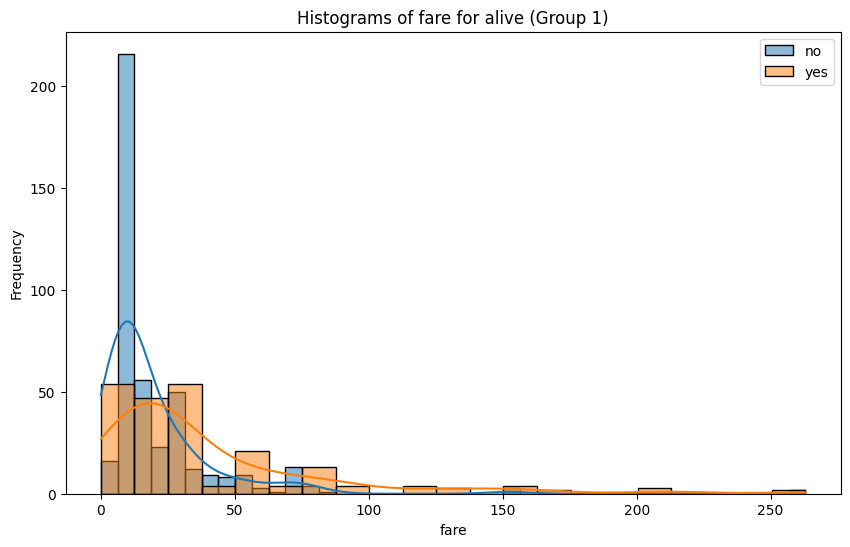

Respuesta Cherbourg:


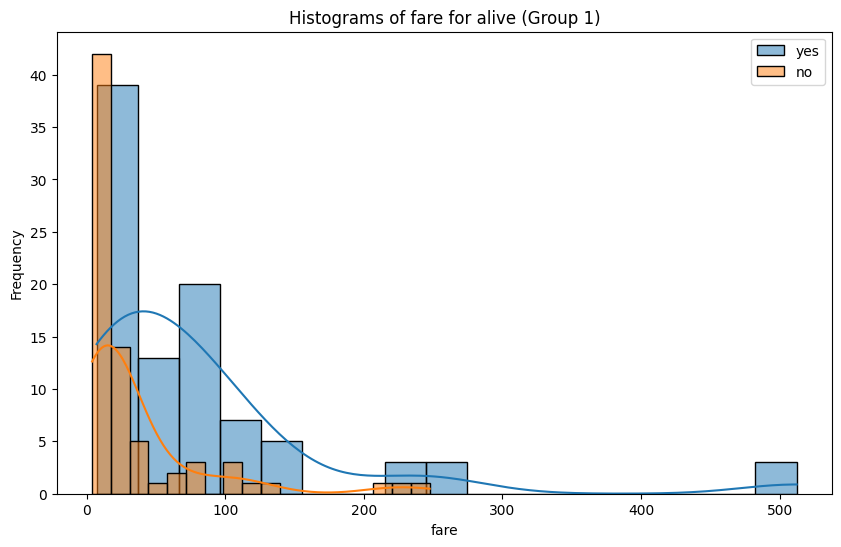

Respuesta Queenstown:


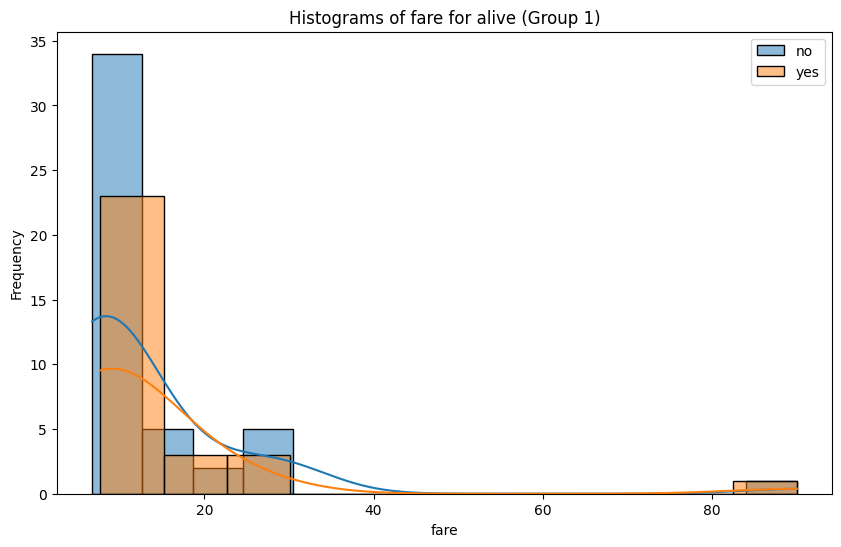

In [41]:
trivariant_analysis(df_titanic, "embark_town","alive","fare", 2)


7. *Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?*

(2,)


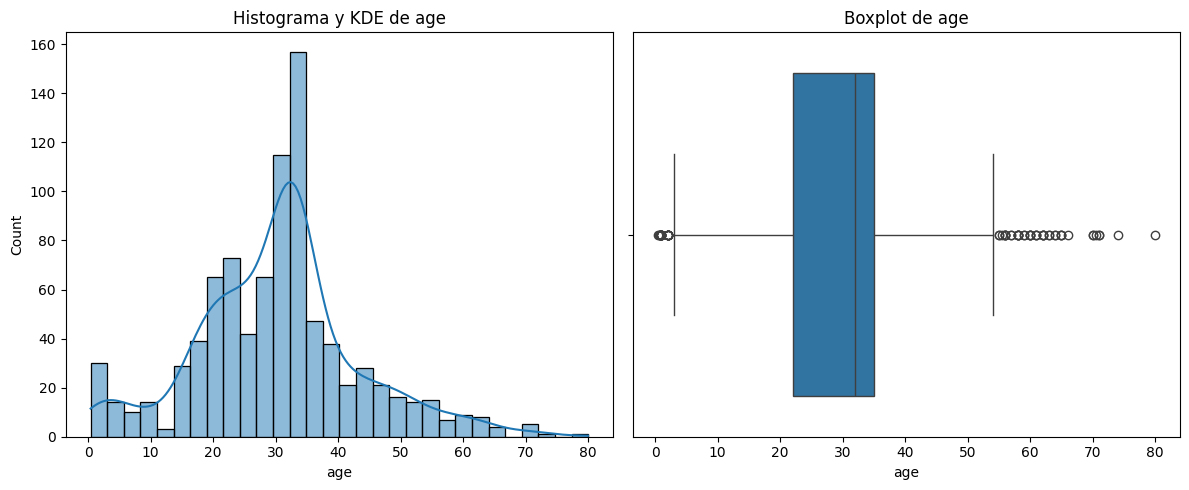

In [42]:
plot_combined_graphs(df_titanic,["age"])

In [43]:
df_titanic.age.describe()

count    891.000000
mean      30.319458
std       13.063839
min        0.420000
25%       22.000000
50%       32.000000
75%       35.000000
max       80.000000
Name: age, dtype: float64

In [44]:
bins = [0,22,32,35,80]
df_titanic["cat_age"] = pd.cut(df_titanic.age, bins = bins, labels = ["under_22","under_32","under_35","under_80"])

Respuesta under_22:


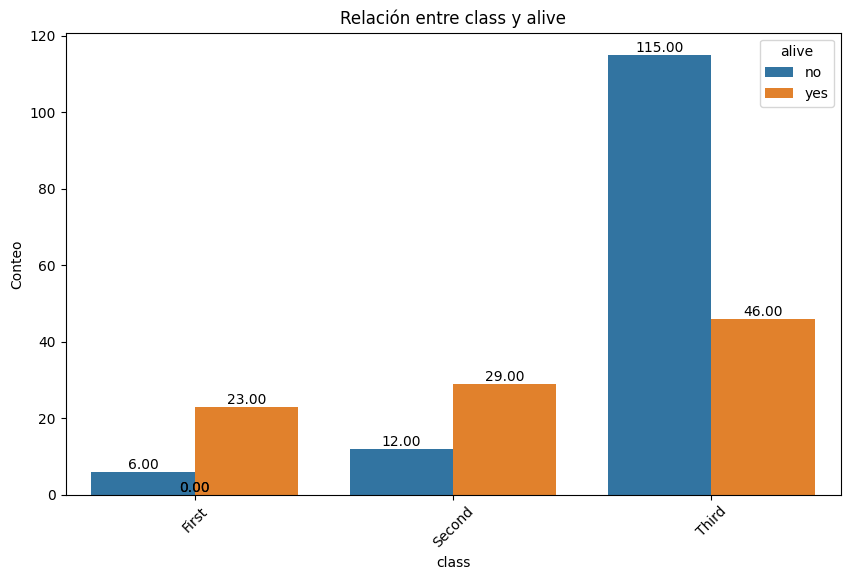

Respuesta under_80:


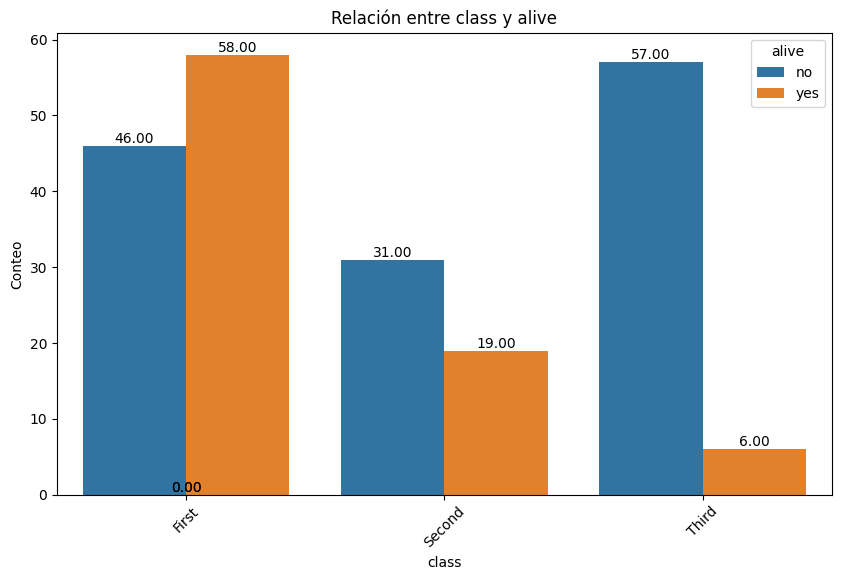

Respuesta under_32:


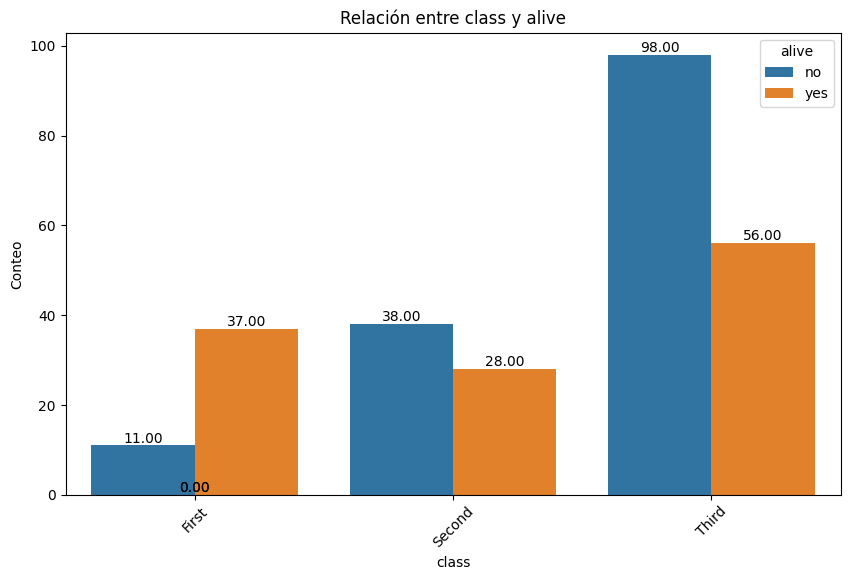

Respuesta under_35:


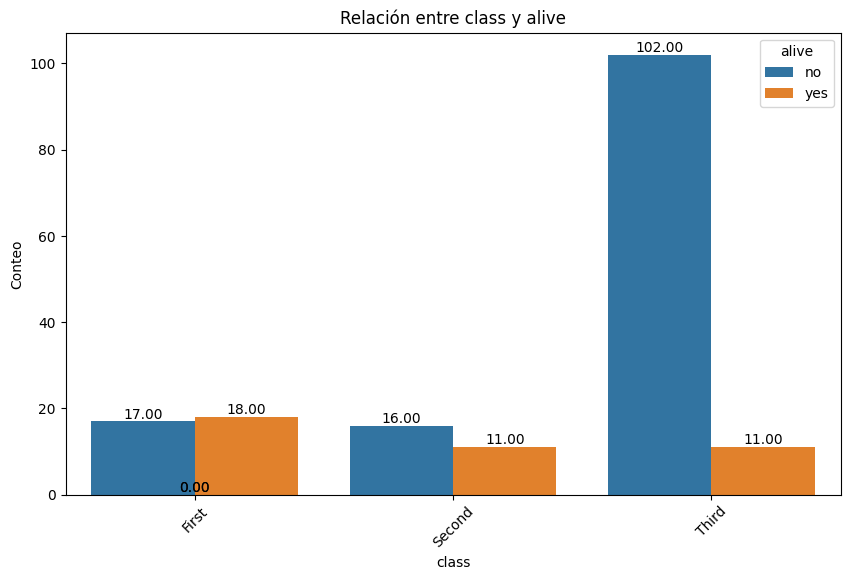

In [45]:
tricategorical_analysis(df = df_titanic, directora = "cat_age", otras = ["alive","class"], muestra_valores = True)

Cuanto más joven y clase más alta, más tasa de supervivencia.


8. *Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?*

<Axes: xlabel='alive', ylabel='age'>

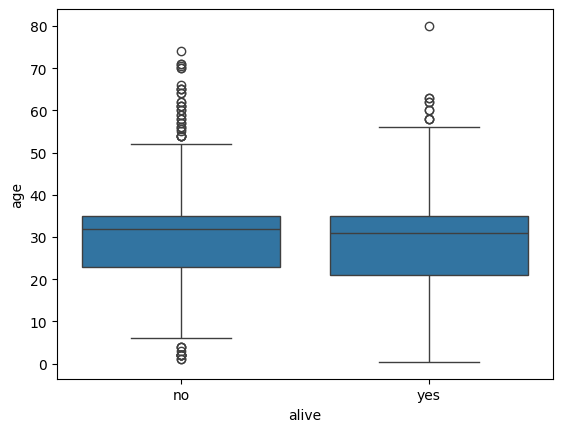

In [46]:
sns.boxplot(data=df_titanic, x="alive", y="age")

<Axes: xlabel='alive', ylabel='fare'>

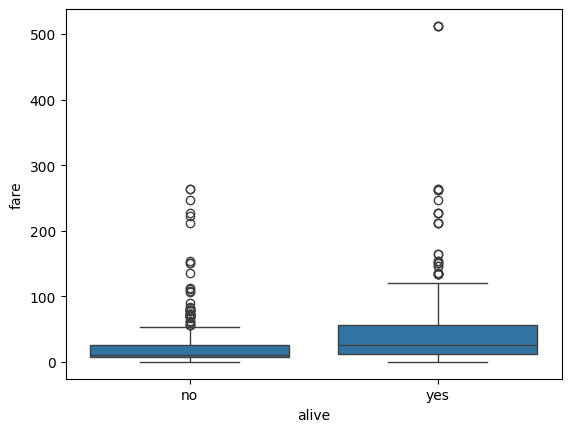

In [47]:
sns.boxplot(data=df_titanic, x="alive", y="fare")

<Axes: xlabel='age', ylabel='fare'>

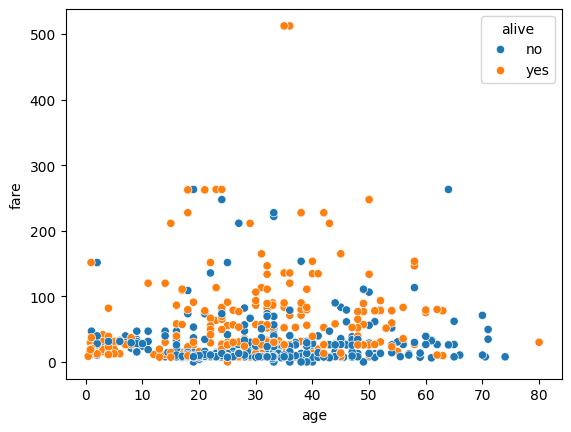

In [48]:
sns.scatterplot(
    data=df_titanic,
    x="age",
    y="fare",
    hue="alive"
)

In [49]:
col_directora = "alive"
col_1 = "fare"
col_2 = "age"
diccionario_multivariante = {}
for valor in df_titanic[col_directora].unique():
    diccionario_multivariante[valor] = df_titanic.loc[df_titanic[col_directora] == valor,[col_2,col_1]]

Respuesta no:


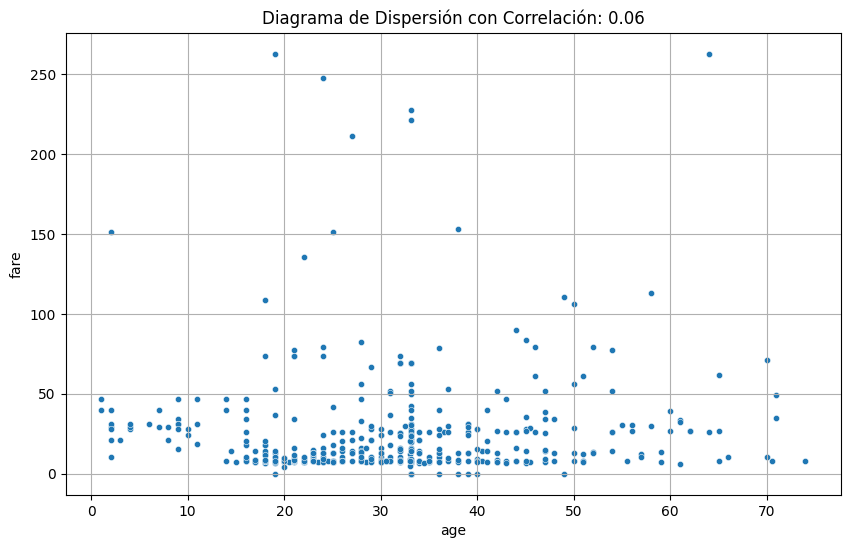

Respuesta yes:


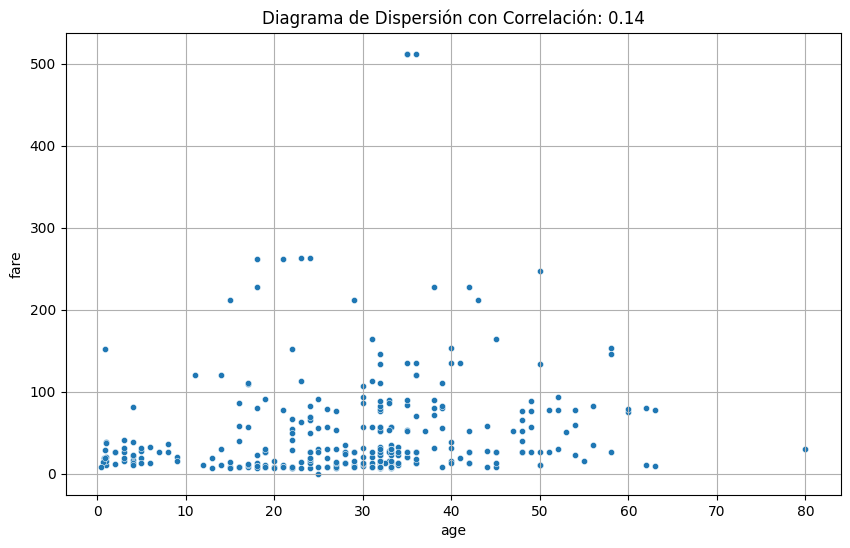

In [50]:
for valor,df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    grafico_dispersion_con_correlacion(df_datos,col_2,col_1, tamano_puntos=20, mostrar_correlacion= True)

In [51]:
df_titanic.groupby("alive")[["age","fare"]].mean()

,age,fare
alive,,
no,31.169758,22.117887
yes,28.954503,48.395408


In [52]:
df_titanic.groupby("alive")[["age","fare"]].median()

,age,fare
alive,,
no,32.0,10.5
yes,31.0,26.0


Relación general entre edad y supervivencia, y entre precio y supervivencia. Mayor supervivencia entre edades más bajas (niños > hombres, y mujeres con edad ligeramente inferior a hombres y mucha más supervivencia). Clase (y precio) directamente correlacionado con supervivencia. 

## #2 Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #2.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

In [53]:
df_viajes = pd.read_csv("../data/dataset_viajes_jun23.csv")


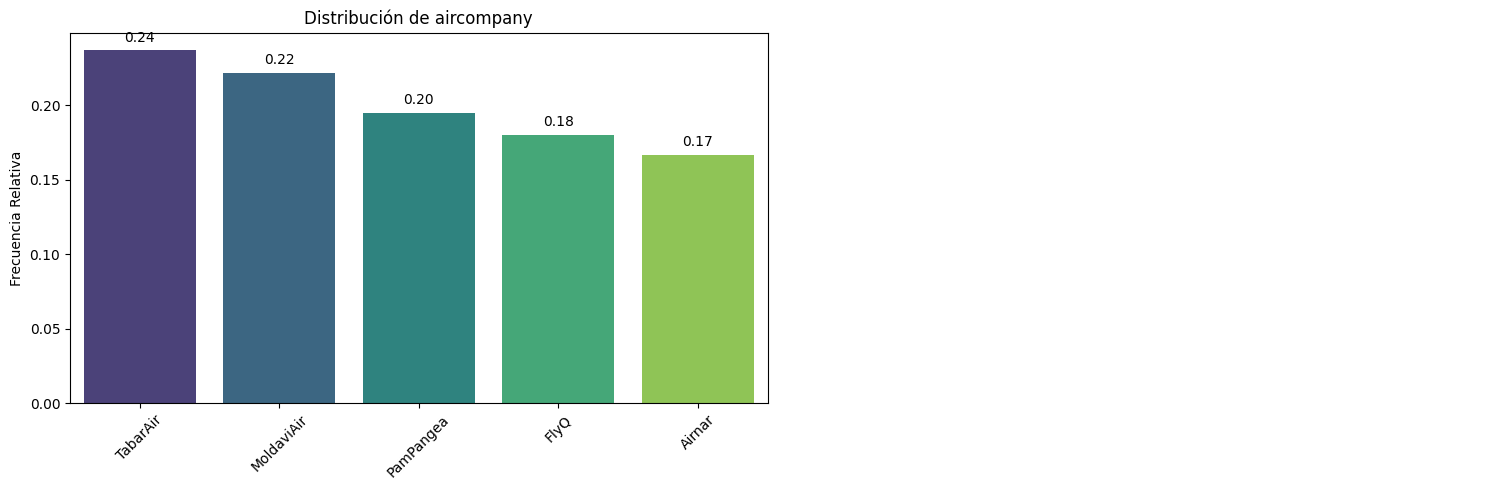

In [54]:
pinta_distribucion_categoricas(df_viajes,["aircompany"], relativa= True, mostrar_valores= True)

(2,)


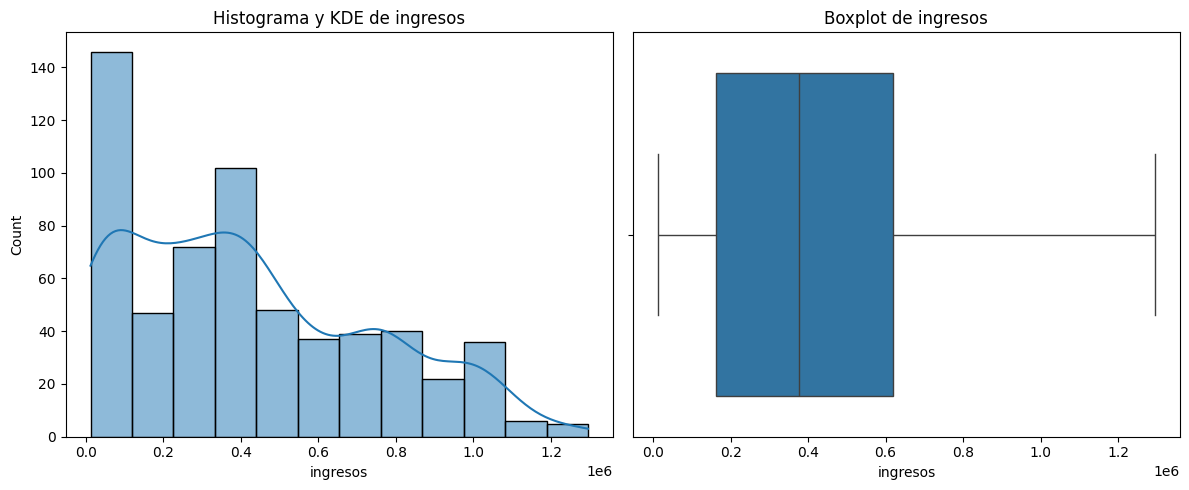

In [55]:
plot_combined_graphs(df_viajes,["ingresos"])

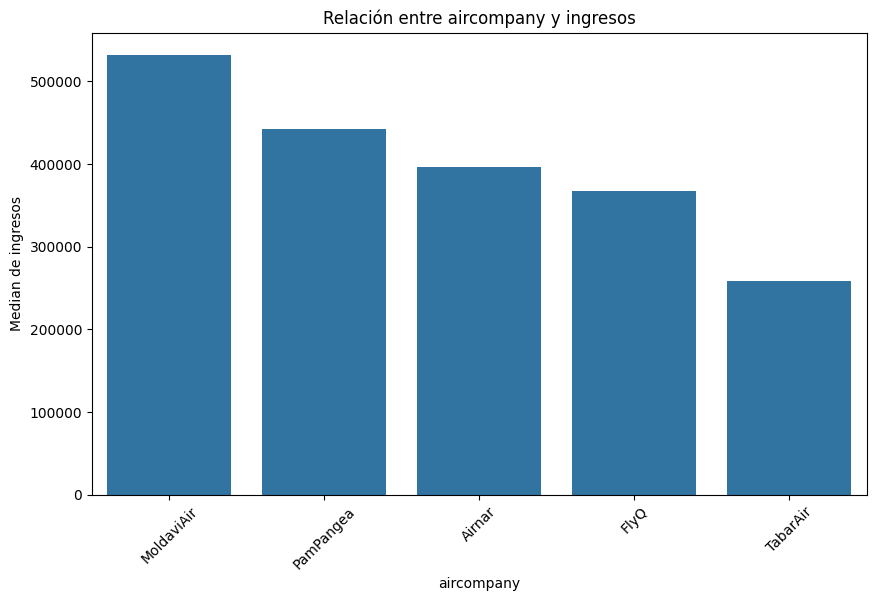

In [56]:
plot_categorical_numerical_relationship(df_viajes, "aircompany","ingresos",measure="median")

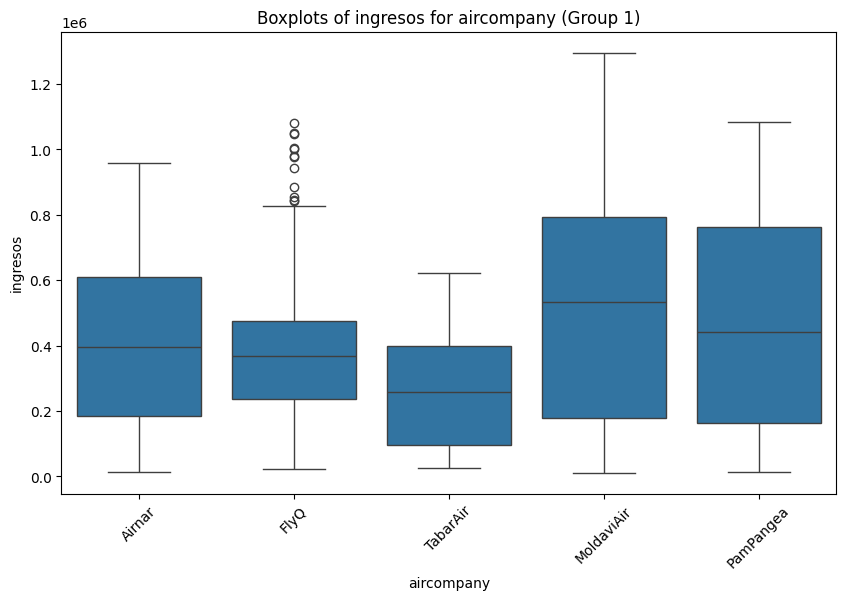

In [57]:
plot_grouped_boxplots(df_viajes,"aircompany","ingresos")

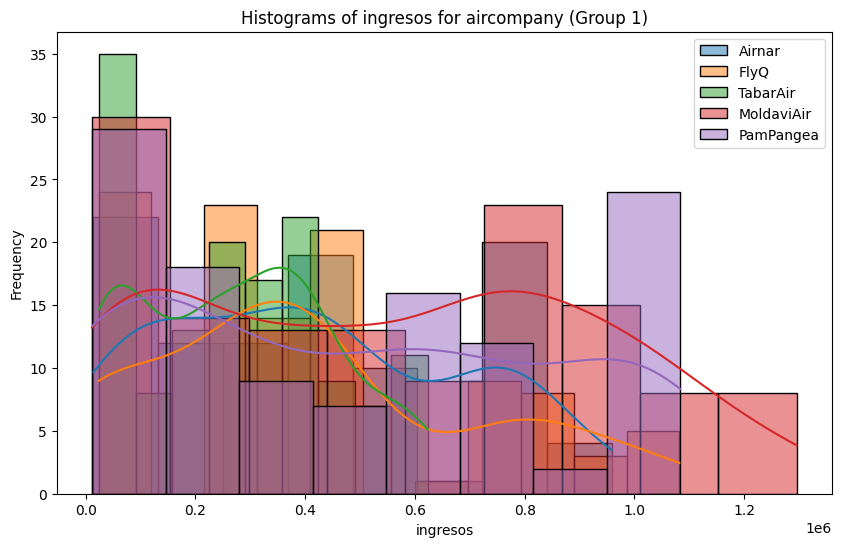

In [58]:
plot_grouped_histograms(df_viajes,"aircompany","ingresos", group_size = 5)

In [59]:
df_viajes.groupby("aircompany").agg({"ingresos": sum, "destino": len})

,ingresos,destino
aircompany,,
Airnar,40529397.82,100
FlyQ,43374852.87,108
MoldaviAir,72894268.81,133
PamPangea,55974794.70,117
TabarAir,38487996.70,142


In [60]:
df = df_viajes.groupby("aircompany").agg({"ingresos": sum, "destino": len})
(df["ingresos"]/df["destino"]).sort_values(ascending= False)

aircompany
MoldaviAir    548077.209098
PamPangea     478417.048718
Airnar        405293.978200
FlyQ          401619.008056
TabarAir      271042.230282
dtype: float64

TabarAir tiene los ingresos más bajos, el máximo de viajes y los ingresos más bajos por viaje de todas las compañías.

### #2.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

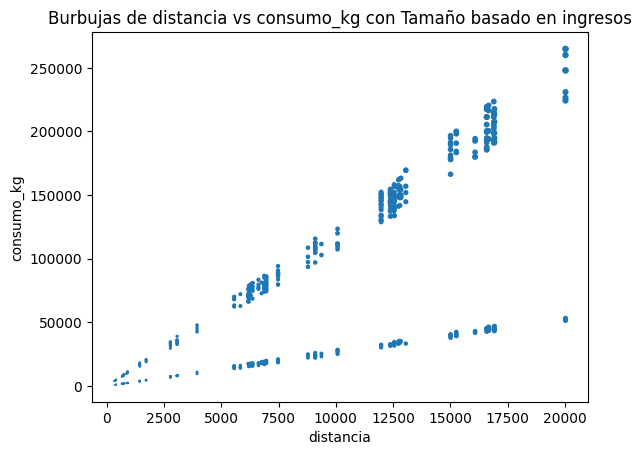

In [70]:
bubble_plot(df_viajes,"distancia","consumo_kg","ingresos", scale=100000)

Claramente hay una forma de realizar los viajes de manera más eficiente y rentable economicamente 

### #2.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Realiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?

(2,)


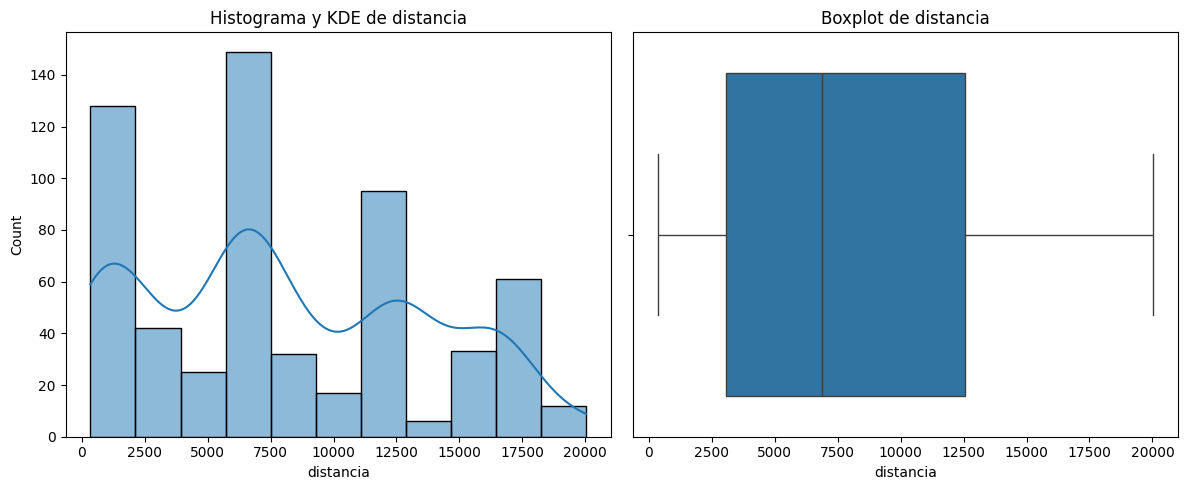

In [71]:
plot_combined_graphs(df_viajes,["distancia"])

In [86]:
df_viajes["cat_vuelo"] = pd.cut(df_viajes["distancia"], bins = [0,5500, 7000,12500, df_viajes.distancia.max()], labels = ["cat1","cat2","cat3","cat4"])

In [87]:
df_viajes.cat_vuelo.value_counts()

cat_vuelo
cat1    176
cat4    163
cat2    150
cat3    111
Name: count, dtype: int64

In [88]:
pd.crosstab(df_viajes["aircompany"],df_viajes["cat_vuelo"])

cat_vuelo,cat1,cat2,cat3,cat4
aircompany,,,,
Airnar,31,21,31,17
FlyQ,24,43,13,28
MoldaviAir,34,19,11,69
PamPangea,33,23,12,49
TabarAir,54,44,44,0


In [89]:
col_directora = "cat_vuelo"
col_1 = "ingresos"
col_2 = "consumo_kg"
diccionario_multivariante = {}
for valor in df_viajes[col_directora].unique():
    diccionario_multivariante[valor] = df_viajes.loc[df_viajes[col_directora] == valor,[col_2,col_1]]

Respuesta cat1:


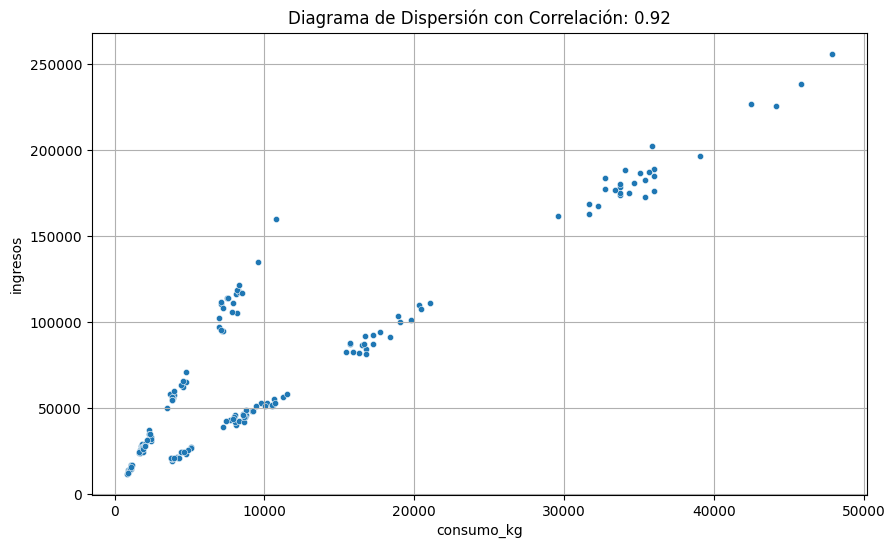

Respuesta cat4:


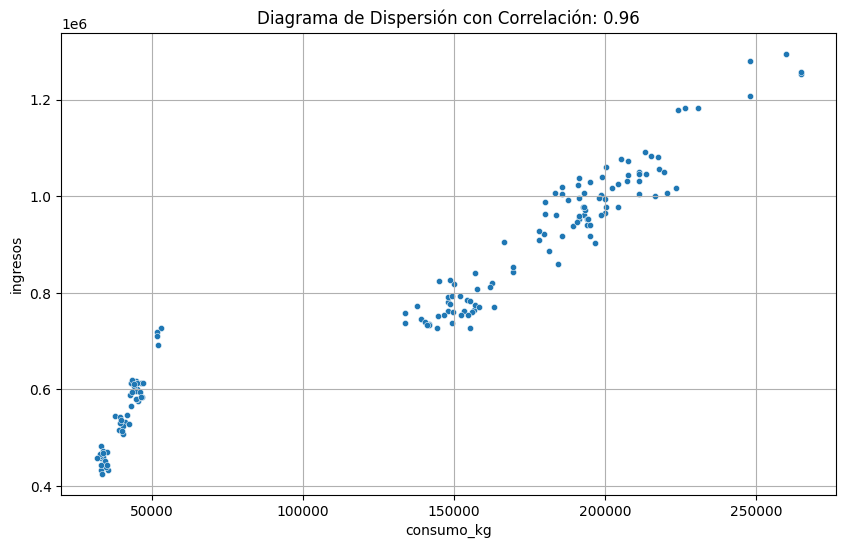

Respuesta cat3:


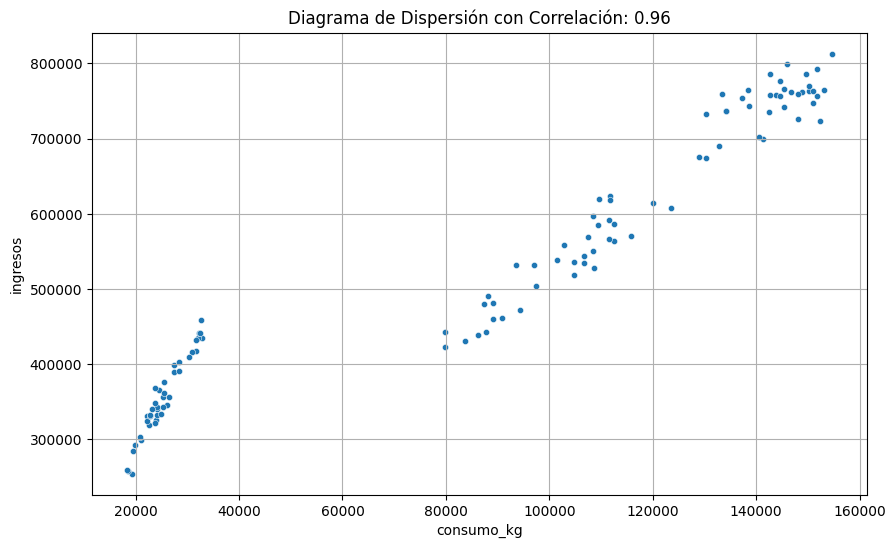

Respuesta cat2:


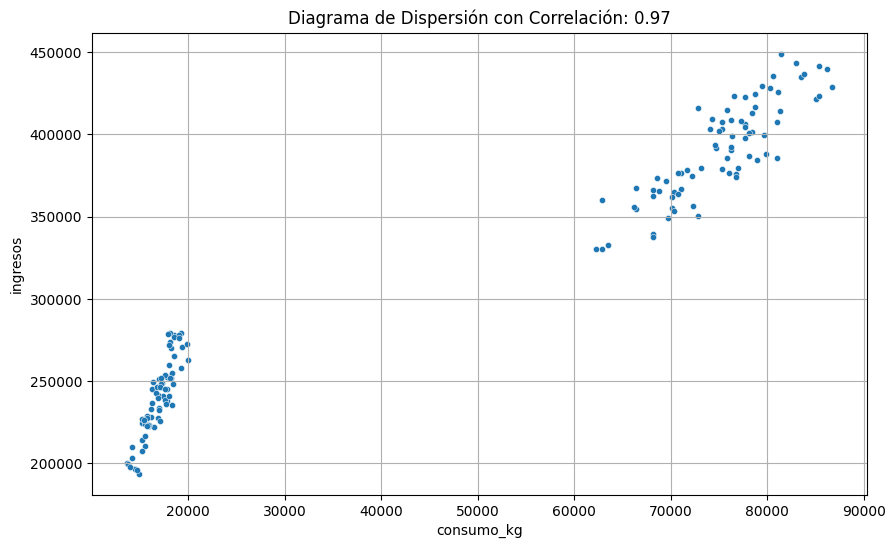

In [90]:
for valor,df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    grafico_dispersion_con_correlacion(df_datos,col_2,col_1, tamano_puntos=20, mostrar_correlacion= True)

In [91]:
df_viajes.groupby("cat_vuelo")["ingresos"].mean()

cat_vuelo
cat1     74065.190455
cat2    318443.784733
cat3    535755.798739
cat4    803621.938712
Name: ingresos, dtype: float64

### Extra:

#1 Consejos para encontrar "objetivos":

Si partes de un dataset que te parece interesante pero sin pregruntras claras, haz como hicimos con el dataset de Aviones. Describe, prioriza a ojo tus variables, realiza un análisis univariante completo, realiza un análisis bivariante ente las parejas de variables que te parecieron más intereantes. Llegados a este punto si el dataset tiene riqueza informativa, algo diferente tiene que haber aparecido (otra cosa es que sea interesante para ti :-)).  

Fíjate en lo que encontramos en el dataset de viajes: la empresa de más vuelos es la que menos ingresos tiene o la existencia clara de una línea de vuelos más eficientes en consumo que otros y otra de mayor ingresos por consumo. Lo siguiente es explorar esos puntos normalmente intentando contestar a: ¿por qué pasa?¿dónde,cuándo o cómo pasa?  

Busca esas "notas discordantes" en tu dataset, ya de por sí son mensajes del análisis. Ordénalas por importancia (importancia = impactan en ingresos, impactan en la calidad de la vida de las personas, impactan en el coste y poco más hay) e intenta entender por qué suceden esas notas discordantes, cómo solucionarlas o aprovecharlas y ya tienes objeetivos para el EDA; incluso si no encuentras respuesta siempre tendras esas notas discordantes, la conclusión de que no se puede avanzar con los datos que se tienen y los próximos pasos de encontrar más información para explicar lo que ocurre.

#2 Contestando a las preguntas de "Viajes".

- Necesitamos identificar esas líneas eficientes, para ello crea una variable que mida el ingreso por kilogramo consumido y otra que mida el kilogramo consumido por kilómetro. Haz el análisis univariante de las mismas intentando encontrar una diferencia clara entre viajes eficientes y no eficientes (que sabemos que existe). Fija un umbral para indicar si un viaje es supereficiente o si no lo es
- Crea esa variable de eficiencia binaria de eficiencia.
- Ahora haz el análisis bivariante de esa eficiencia y las compañías aéreas (queremos ver si realmente eso explica la situación de TabarAir). 
- Para nota: Hacer los análisis multivariante por compañía, eficiencia, tipo de avión y compañía, eficiencia, destino e incluso el de compañía, eficiencia, origen, destino.
- Con todo ello deberías poder encontrar si hay respuesta a la situación de TabarAir además de poder mostrar otros datos interesantes.

In [92]:
df_viajes["ingreso_kg"] = df_viajes["ingresos"]/df_viajes["consumo_kg"]
df_viajes["consumo_km"] = df_viajes["consumo_kg"]/df_viajes["distancia"]


In [93]:
df_viajes.describe()

,distancia,consumo_kg,duracion,ingresos,ingreso_kg,consumo_km
count,600.000000,600.000000,600.000000,6.000000e+02,600.000000,600.000000
mean,8071.003333,68240.520508,635.873333,4.187689e+05,8.904848,7.934756
std,5550.244086,67441.849592,450.474786,3.182858e+05,4.407691,4.537013
min,344.000000,835.920000,42.000000,1.179785e+04,4.554666,2.430000
25%,3073.000000,15733.520400,224.000000,1.627668e+05,5.131672,2.660600
50%,6877.000000,36033.998000,542.000000,3.754817e+05,5.459427,11.086400
75%,12553.000000,111717.652800,876.000000,6.188420e+05,13.855693,11.906800
max,20029.000000,264876.314560,1721.000000,1.295516e+06,16.213469,13.224640


(2, 2)


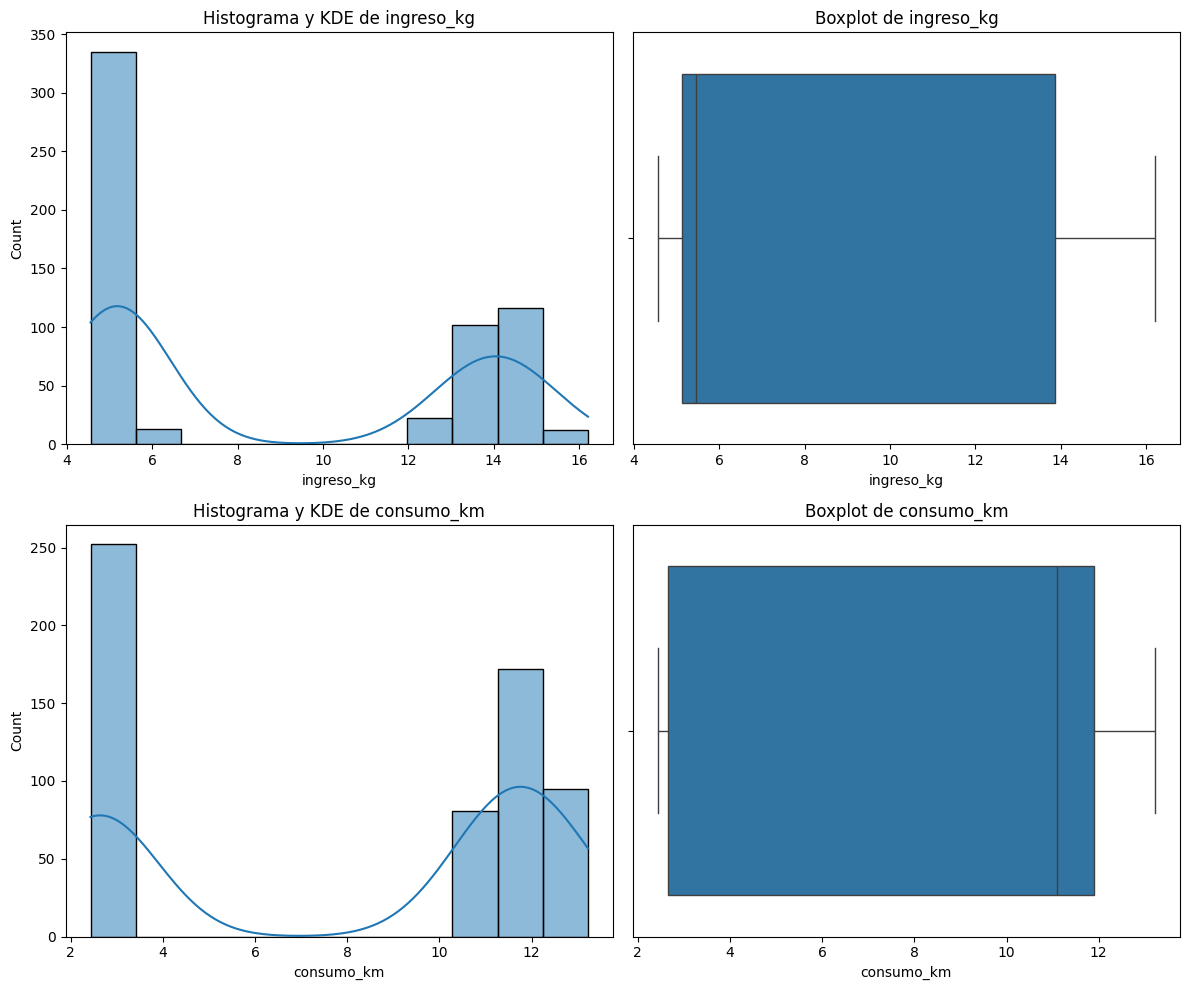

In [94]:
plot_combined_graphs(df_viajes,["ingreso_kg","consumo_km"])

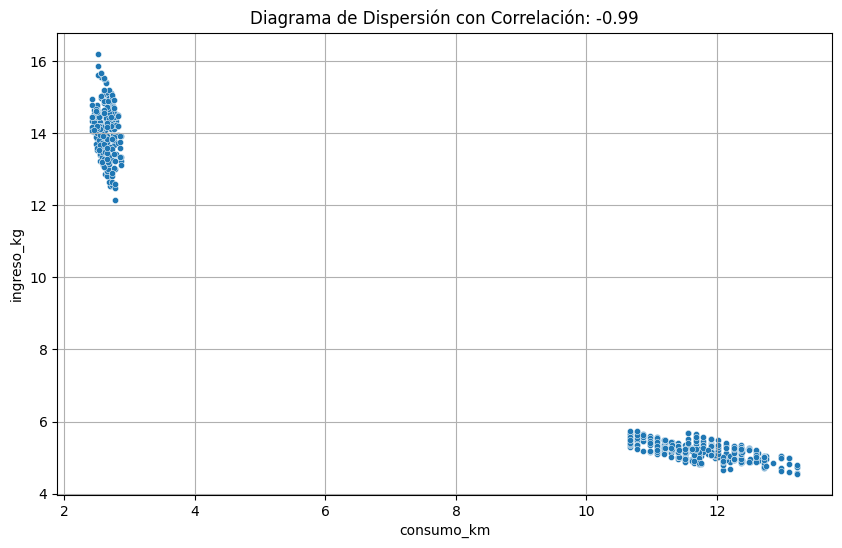

In [104]:
grafico_dispersion_con_correlacion(df_viajes,'consumo_km', 'ingreso_kg', tamano_puntos=20, mostrar_correlacion= True)

In [105]:
df_viajes["eficiente_ingreso"] = df_viajes.ingreso_kg >= 12
df_viajes["eficiente_consumo"] = df_viajes.consumo_km <= 4
df_viajes["supereficiente"] = (df_viajes["eficiente_ingreso"]) & (df_viajes["eficiente_consumo"])

In [106]:
df_viajes.groupby("eficiente_ingreso")["eficiente_consumo"].mean()

eficiente_ingreso
False    0.0
True     1.0
Name: eficiente_consumo, dtype: float64

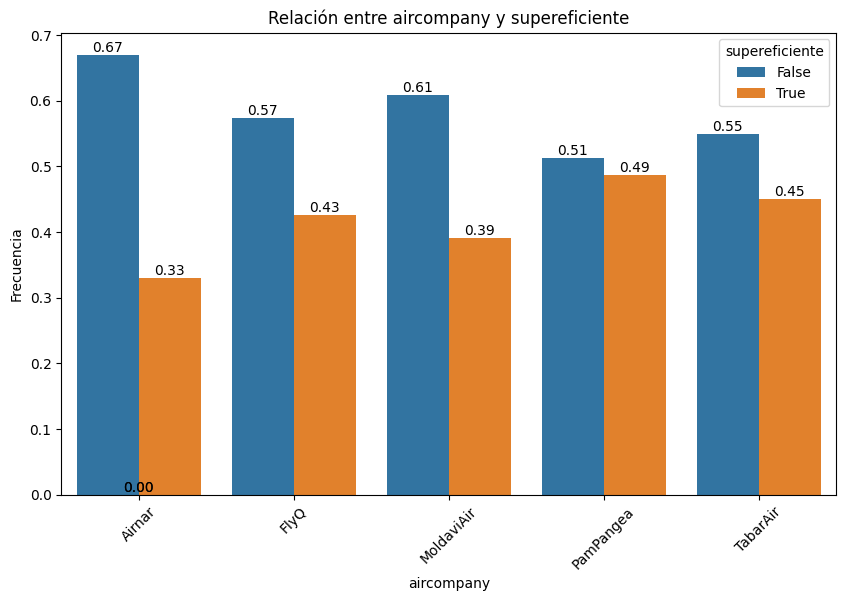

In [114]:
plot_categorical_relationship_fin(df_viajes, "aircompany", "supereficiente", relative_freq = True, show_values = True)

In [112]:
df_viajes.groupby("aircompany").agg({"ingresos": sum, "destino": len, "consumo_kg": sum, "distancia": sum})

,ingresos,destino,consumo_kg,distancia
aircompany,,,,
Airnar,40529397.82,100,6.731762e+06,759821
FlyQ,43374852.87,108,7.186780e+06,826289
MoldaviAir,72894268.81,133,1.232397e+07,1386026
PamPangea,55974794.70,117,8.951536e+06,1106492
TabarAir,38487996.70,142,5.750263e+06,763974


In [109]:
df_viajes.loc[df_viajes.supereficiente].groupby("aircompany").agg({"ingresos": sum, "destino": len, "consumo_kg": sum, "distancia": sum})

,ingresos,destino,consumo_kg,distancia
aircompany,,,,
Airnar,8721813.75,33,6.297195e+05,238838
FlyQ,10547305.45,46,7.545022e+05,285035
MoldaviAir,16374674.69,52,1.215658e+06,459579
PamPangea,16723934.00,57,1.225525e+06,463329
TabarAir,13351546.24,64,9.415297e+05,352937


In [110]:
df_viajes.loc[df_viajes.supereficiente == False].groupby("aircompany").agg({"ingresos": sum, "destino": len, "consumo_kg": sum, "distancia": sum})

,ingresos,destino,consumo_kg,distancia
aircompany,,,,
Airnar,31807584.07,67,6.102042e+06,520983
FlyQ,32827547.42,62,6.432278e+06,541254
MoldaviAir,56519594.12,81,1.110831e+07,926447
PamPangea,39250860.70,60,7.726011e+06,643163
TabarAir,25136450.46,78,4.808733e+06,411037


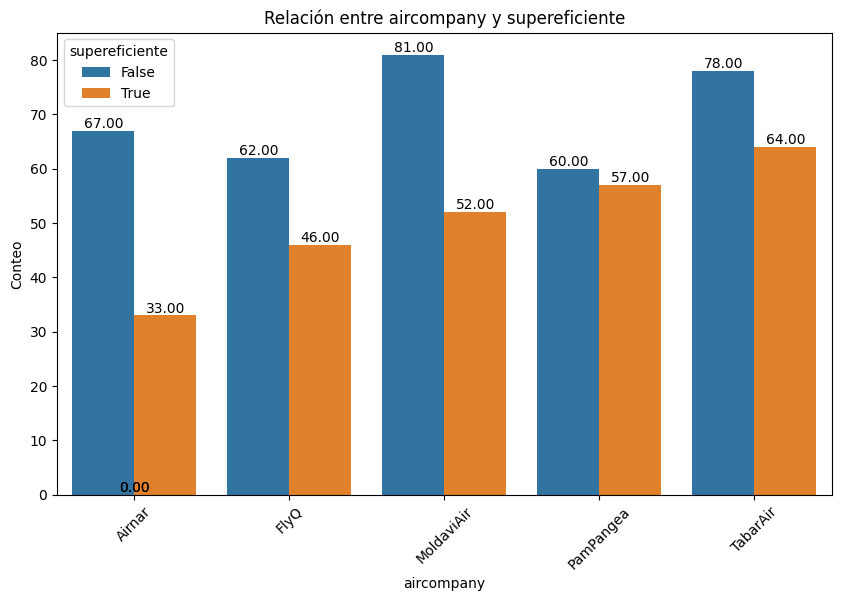

In [119]:
plot_categorical_relationship_fin(df_viajes, 'aircompany', 'supereficiente', relative_freq=False, show_values=True)

In [123]:
df_viajes.groupby('aircompany').agg({
    'ingresos': sum,
    'destino': len,
    'consumo_kg': sum,
    'distancia': sum
}).round(0)

,ingresos,destino,consumo_kg,distancia
aircompany,,,,
Airnar,40529398.0,100,6731762.0,759821
FlyQ,43374853.0,108,7186780.0,826289
MoldaviAir,72894269.0,133,12323971.0,1386026
PamPangea,55974795.0,117,8951536.0,1106492
TabarAir,38487997.0,142,5750263.0,763974


Visualmente la eficiencia explica parte del problema de TabarAir.  
Tiene buena proporción de vuelos supereficientes.  
Pero sus ingresos totales son más bajos que los líderes.  
Esto sugiere que el problema no es solo de consumo, ya que tiene mayor cantidad de vuelos supereficientes, sino también de cobro, o precio de esos vuelos.  

TabarAir tiene los vuelos más eficientes en ingresos por kilómetro recorrido y consumo por kilómetro, pero ¿es la compañía que menos cobra por esos vuelos? Al menos es la que menos ingresos percibe.

In [132]:
df_viajes.groupby(['aircompany', 'supereficiente'])['destino'].agg(['count'])

count
aircompany supereficiente       
Airnar     False              67
           True               33
FlyQ       False              62
           True               46
MoldaviAir False              81
           True               52
PamPangea  False              60
           True               57
TabarAir   False              78
           True               64

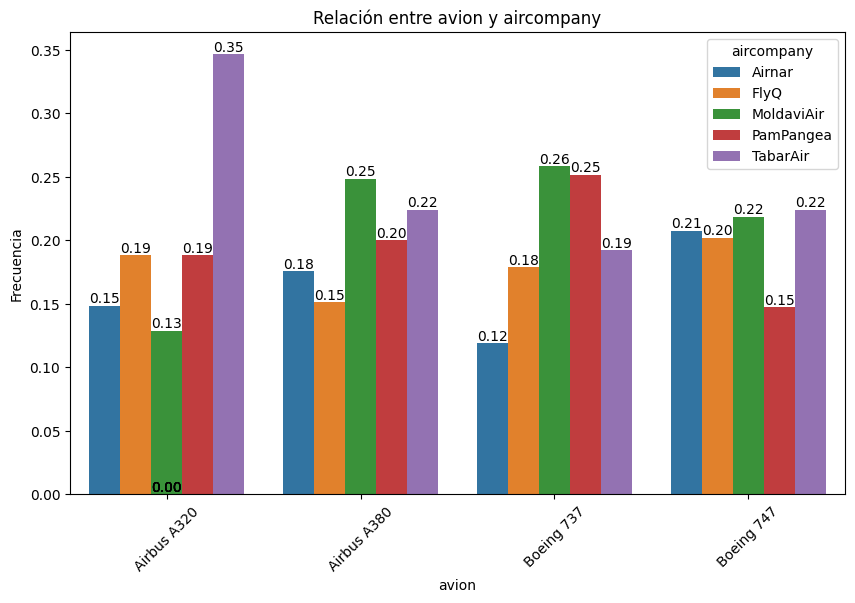

In [152]:
plot_categorical_relationship_fin(df_viajes, 'avion', 'aircompany', relative_freq=True, show_values=True)

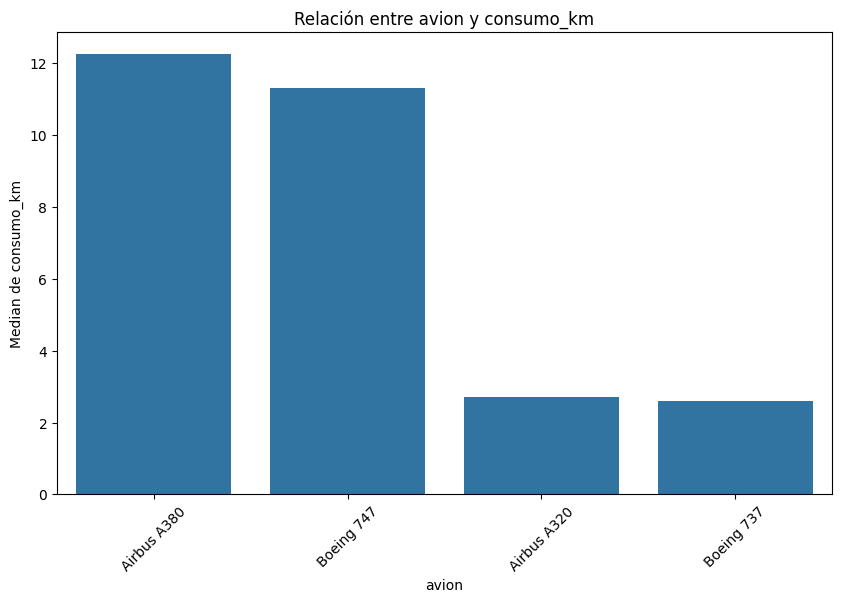

In [156]:
plot_categorical_numerical_relationship(df_viajes, "avion","consumo_km",measure="median")

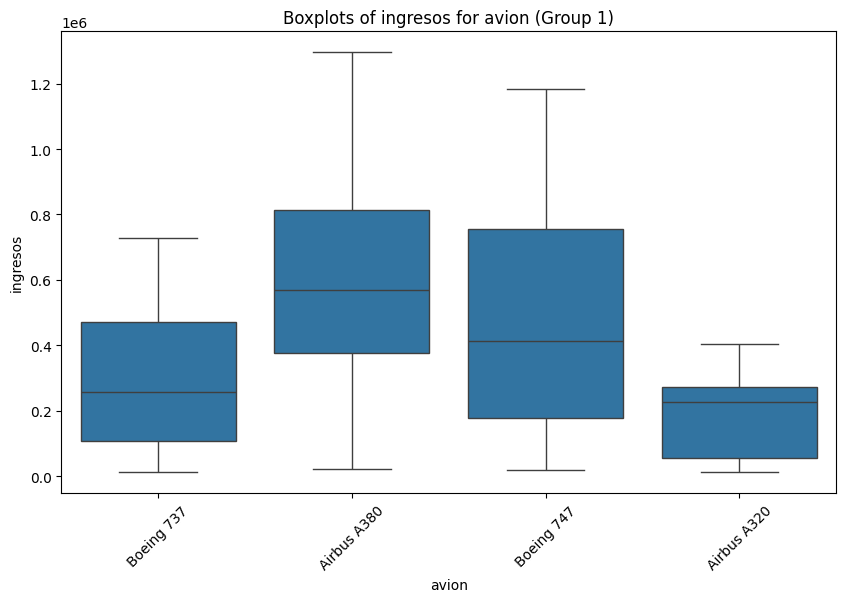

In [157]:
plot_grouped_boxplots(df_viajes,"avion","ingresos")

In [159]:
df_viajes.groupby("avion")["ingreso_kg"].mean()

avion
Airbus A320    14.554919
Airbus A380     5.125501
Boeing 737     13.707405
Boeing 747      5.231344
Name: ingreso_kg, dtype: float64

In [160]:
df_viajes.groupby("avion")["consumo_km"].mean()

avion
Airbus A320     2.707539
Airbus A380    12.271451
Boeing 737      2.591481
Boeing 747     11.318520
Name: consumo_km, dtype: float64

In [137]:
df_viajes.groupby("avion").agg({"ingresos": sum, "destino": len, "consumo_kg": sum, "distancia": sum})

,ingresos,destino,consumo_kg,distancia
avion,,,,
Airbus A320,18406653.85,101,1.275444e+06,467460
Airbus A380,95953829.66,165,1.893685e+07,1530289
Boeing 737,47312620.28,151,3.491491e+06,1332258
Boeing 747,89588207.11,183,1.724053e+07,1512595


In [139]:
df_viajes.loc[df_viajes.supereficiente].groupby("avion").agg({"ingresos": sum, "destino": len, "consumo_kg": sum, "distancia": sum})

,ingresos,destino,consumo_kg,distancia
avion,,,,
Airbus A320,18406653.85,101,1.275444e+06,467460
Boeing 737,47312620.28,151,3.491491e+06,1332258


In [140]:
df_viajes.loc[df_viajes.supereficiente == False].groupby("avion").agg({"ingresos": sum, "destino": len, "consumo_kg": sum, "distancia": sum})

,ingresos,destino,consumo_kg,distancia
avion,,,,
Airbus A380,95953829.66,165,1.893685e+07,1530289
Boeing 747,89588207.11,183,1.724053e+07,1512595


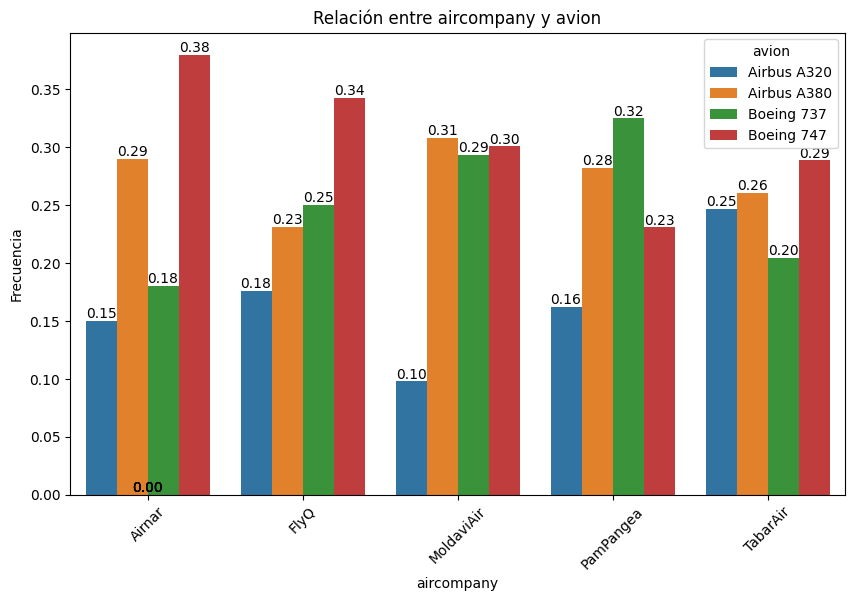

In [150]:
plot_categorical_relationship_fin(df_viajes, 'aircompany', 'avion', 'supereficiente', show_values= True)

Vemos que los aviones con vuelos supereficientes son Boeing 737 y Airbus A320. Ambos aviones diseñados para rutas cortas o medias (no largas distancias). Esto nos indica que son las rutas más cortas más habitualmente las más eficientes y economicamente rentables. Pero no nos da información suficiente para saber si la elección de avión por parte de TabarAir es relevante en este caso.

In [163]:
tabla_contingencia = pd.crosstab(df_viajes["avion"],df_viajes["supereficiente"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 600.0
P-Value: 1.0078435921645548e-129
Grados de Libertad: 3
Tabla de Frecuencias Esperadas:
 [[ 58.58  42.42]
 [ 95.7   69.3 ]
 [ 87.58  63.42]
 [106.14  76.86]]


El p-valor nos indica que hay una correlación entre tipo de avion y supereficiencia, pero eso es por el tipo de ruta que recorre cada uno.

Queda mucho estudio por hacer, yo de momento me rindo, que no he empezado el EDA.